In [4]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import pandas as pd
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames
import re
big_plt_font()

In [5]:
data_dir = '/home/electron/data/experiment_07082026'
all_files = list_filenames(data_dir)

In [6]:
file = load_latest_data() 
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data[0])) 
data_avg = np.mean(data, axis=0) 
plot(t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')

KeyError: 'all_meas'

In [7]:
file['filename']

'/home/electron/data/experiment_07082026/TipVoltageSweep_19-30-33.h5'

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Your existing data setup remains here ---
# (Ensure t_axis and data are defined above this cell)
file = load_latest_data() #load_h5_data('/home/electron/data/experiment_07082026/RFPowerSweepOnOff_11-00-56.h5') #
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data[0])) 

# 1. Setup UI elements (Slider and Navigation Buttons)
slider = widgets.IntSlider(
    value=0, 
    min=0, 
    max=len(data) - 1, 
    step=1, 
    description='Index (i):'
)

btn_prev = widgets.Button(
    description='Prev',
    button_style='info',     # Light blue styling
    icon='arrow-left'        # Left arrow icon
)

btn_next = widgets.Button(
    description='Next',
    button_style='primary',  # Darker blue styling
    icon='arrow-right'       # Right arrow icon
)

# Output container to catch the plot and refresh it cleanly
plot_output = widgets.Output()

# 2. Plotting logic wrapped in an output handler
def draw_plot(i):
    with plot_output:
        clear_output(wait=True)  # Instantly clears the old plot
        
        fig, ax = plt.subplots(figsize=(7, 4))
        # Using your exact variables and scalings
        ax.plot(t_axis * 1e3, data[i], color='blue', lw=2)
        
        ax.set_title(f"Plotting dataset i = {i}")
        ax.set_xlabel("Wait time (ms)")
        ax.set_ylabel("Power (dBm)")
        ax.grid(True)
        plt.show()

# 3. Define event behaviors
def on_slider_change(change):
    draw_plot(change['new'])

def on_next_clicked(b):
    # Advances the slider, looping back to 0 if at the end
    if slider.value < slider.max:
        slider.value += 1
    else:
        slider.value = 0

def on_prev_clicked(b):
    # Rewinds the slider, looping to the end if at 0
    if slider.value > slider.min:
        slider.value -= 1
    else:
        slider.value = slider.max

# Link actions to the widgets
slider.observe(on_slider_change, names='value')
btn_next.on_click(on_next_clicked)
btn_prev.on_click(on_prev_clicked)

# 4. Pack layouts in a clean media-player style order and display
controls = widgets.HBox([btn_prev, slider, btn_next])
ui = widgets.VBox([controls, plot_output])

display(ui)

# Render the very first plot upon cell execution
draw_plot(slider.value)

KeyError: 'all_meas'

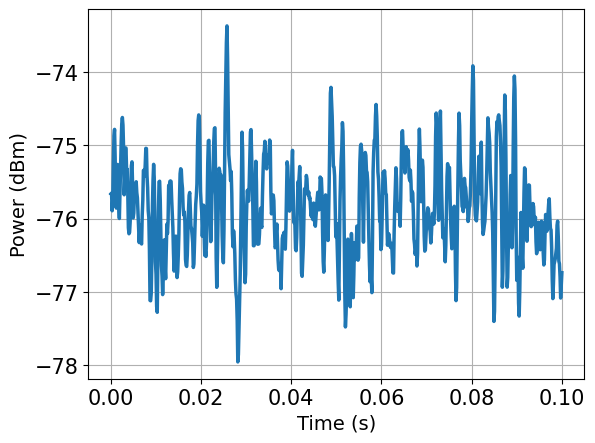

In [9]:
file2 = load_h5_data('data/experiment_07082026/RFPowerSweepOnOff_11-00-56.h5', base='/home/electron/') 
data2 = file2['all_meas'] 
t_seq_end2 = file2['t_data']
t_axis2 = np.linspace(0, t_seq_end2, len(data2[0])) 
data_avg2 = np.mean(data2, axis=0) 
plot(t_axis2, data_avg2, xlabel='Time (s)', ylabel='Power (dBm)')

In [10]:
peak_time = []
for i in range(len(data)): 
    peak_time.append(t_axis[np.argmax(data[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip on', alpha=0.7, density=True)
peak_time = []
for i in range(len(data2)): 
    peak_time.append(t_axis2[np.argmax(data2[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip off', alpha=0.7, density=True)
plt.xlabel('Time at which max power is detected (ms)') 
plt.ylabel('Counts density / 4ms bin') 
plt.legend()
plt.grid() 
plt.show()

NameError: name 'data' is not defined

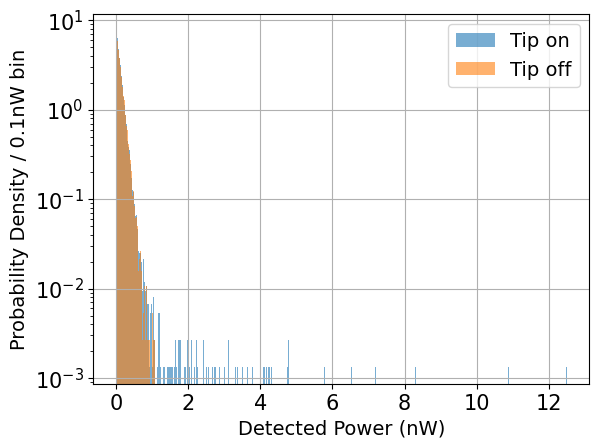

In [207]:
file = load_h5_data('/home/electron/data/experiment_07062026/RFPowerSweepOnOff_19-06-42_data.h5') #load_latest_data()#
data = file['all_meas'] 
file = load_h5_data('/home/electron/data/experiment_07062026/RFPowerSweepOnOff_18-11-16_data.h5')
data2 = file['all_meas']
P_nW = dBm_to_W(np.concatenate(data2, axis=0))*1e9 
P_nW_background = dBm_to_W(np.concatenate(data, axis=0))*1e9
bin_size = 0.01

# counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW)-min(P_nW))/bin_size))#, alpha=0.7, label='Tip on')
# plt.bar(
#     bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
#     counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
#     width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
#     label='Tip on',
#     align='edge',            # Align the bars to start at the left bin edge
#     alpha=0.6                # Transparency
# )

# counts, bin_edges = np.histogram(P_nW_background, bins=int((max(P_nW_background)-min(P_nW_background))/bin_size))#, alpha=0.7, label='Tip off')
# # plt.xscale('log') 
# plt.bar(
#     bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
#     counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
#     width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
#     label='Tip off',
#     align='edge',            # Align the bars to start at the left bin edge
#     alpha=0.6                # Transparency
# )

# If you just want to plot it directly without manual plt.bar:

plt.hist(
    P_nW, 
    bins=int((max(P_nW)-min(P_nW))/bin_size), 
    density=True, # This forces the area to equal 1
    label='Tip on',
    alpha=0.6
)

plt.hist(
    P_nW_background, 
    bins=int((max(P_nW_background)-min(P_nW_background))/bin_size), 
    density=True, # This forces the area to equal 1
    label='Tip off',
    alpha=0.6
)

# plt.xlim(-0.1, 0.2)  # Set the y-axis limits to avoid log(0) issues

plt.yscale('log')
plt.xlabel('Detected Power (nW)') 
plt.ylabel('Probability Density / 0.1nW bin')
plt.grid()
plt.legend()
plt.show()

Calibrated Noise Scale (sigma^2): 0.0589
Single Effective Non-Centrality Parameter (lambda): 0.0900


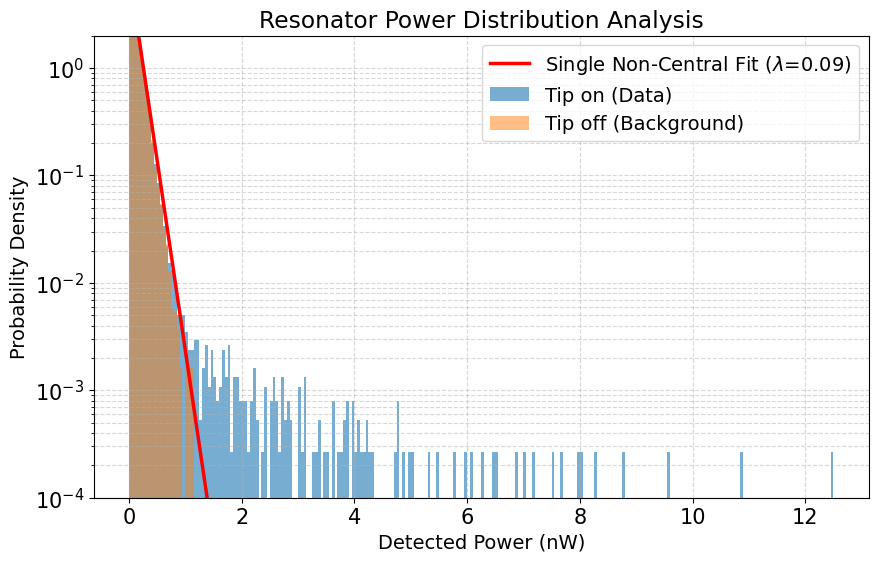

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2
from scipy.optimize import minimize

# --- 1. Load and prepare your data ---
# (Using your data structure variables)
# file = load_latest_data()
# data = file['all_meas'] 
# P_nW = dBm_to_W(np.concatenate(data, axis=0))*1e9 
# P_nW_background = dBm_to_W(np.concatenate(data2, axis=0))*1e9

# Dummy arrays for demonstration purposes—replace with your actual P_nW vectors
np.random.seed(42)
# P_nW_background = np.random.chisquare(df=2, size=50000) * 0.5  # scale=0.5
# Simulating 40% no-signal, 60% varying signal trials
sig_present = np.random.choice(np.array([0, 2.0, 4.0]) , size=50000, p=[0.4, 0.4, 0.2])
# P_nW = np.array([np.random.noncentral_chisquare(df=2, nonc=s**2/0.5) * 0.5 for s in sig_present])

# --- 2. Step 1: Calibrate background noise using 'Tip off' ---
# For a resonator, power is I^2 + Q^2, meaning degrees of freedom (df) = 2
df_fixed = 2
# Fit background to find the noise scale parameter (thermal variance)
bg_df, bg_loc, bg_scale = chi2.fit(P_nW_background, fdf=df_fixed, floc=0)
print(f"Calibrated Noise Scale (sigma^2): {bg_scale:.4f}")

# --- 3. Step 2: Attempt a single Non-Central Chi-Square Fit ---
# We force the noise scale and location to match the background calibration
nc_params = ncx2.fit(P_nW, fdf=df_fixed, floc=0, fscale=bg_scale)
fitted_nc = nc_params[1]
print(f"Single Effective Non-Centrality Parameter (lambda): {fitted_nc:.4f}")

# --- 4. Plotting and Visual Verification ---
bin_size = 0.05
bins = np.arange(min(P_nW_background.min(), P_nW.min()), max(P_nW_background.max(), P_nW.max()) + bin_size, bin_size)

plt.figure(figsize=(10, 6))



# Plot 'Tip on' (Signal Data)
counts_sig, _ = np.histogram(P_nW, bins=bins)
plt.bar(bins[:-1], counts_sig/np.sum(counts_sig)/bin_size, width=bin_size, label='Tip on (Data)', alpha=0.6, align='edge')

# Plot 'Tip off' (Background)
counts_bg, _ = np.histogram(P_nW_background, bins=bins)
plt.bar(bins[:-1], counts_bg/np.sum(counts_bg)/bin_size, width=bin_size, label='Tip off (Background)', alpha=0.5, align='edge')

# Plot the single non-central chi-square fit model
x_axis = np.linspace(bins.min(), bins.max(), 500)
plt.plot(x_axis, ncx2.pdf(x_axis, df=df_fixed, nc=fitted_nc, loc=0, scale=bg_scale), 
         color='red', lw=2.5, label=f'Single Non-Central Fit ($\lambda$={fitted_nc:.2f})')

plt.yscale('log')
plt.ylim(1e-4, 2)
plt.xlabel('Detected Power (nW)')
plt.ylabel('Probability Density')
plt.title('Resonator Power Distribution Analysis')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [45]:
import numpy as np

np.random.seed(42)
num_trials = 50000
df_fixed = 2
bg_scale = 0.5  # This is the background thermal noise scale (\sigma_{noise}^2)

# 1. Background data remain pure central chi-square
P_nW_background = np.random.chisquare(df=df_fixed, size=num_trials) * bg_scale

# 2. Update: Underlying signal voltage amplitude now follows a normal distribution
# Let's say the average voltage amplitude is 2.0 with a standard deviation of 0.6
mu_A = 2.0
sigma_A = 0.6
signal_amplitudes = np.random.normal(loc=mu_A, scale=sigma_A, size=num_trials)

# Ensure no negative amplitudes if needed (though squaring handles it, 
# keeping amplitudes positive matches the physical intuition of our quad integration limits)
signal_amplitudes = np.clip(signal_amplitudes, 0, None)

# 3. Generate P_nW where each point has a unique non-centrality parameter based on its amplitude
# The non-centrality parameter \lambda for scipy/numpy is (Amplitude^2 / noise_scale)
non_centralities = (signal_amplitudes ** 2) / bg_scale

P_nW = np.random.noncentral_chisquare(df=df_fixed, nonc=non_centralities) * bg_scale

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2, norm
from scipy.integrate import quad
from scipy.optimize import minimize

# --- 1. Fix your background noise scale first ---
# (Assume bg_scale is calibrated from your P_nW_background data, e.g., 0.5)
# bg_scale = 0.5  # This is \sigma_{noise}^2
df_fixed = 2
# --- 2. Step 1: Calibrate background noise using 'Tip off' ---
# For a resonator, power is I^2 + Q^2, meaning degrees of freedom (df) = 2
df_fixed = 2
# Fit background to find the noise scale parameter (thermal variance)
bg_df, bg_loc, bg_scale_data = chi2.fit(P_nW_background, fdf=df_fixed, floc=0)
print(f"Calibrated Noise Scale (sigma^2): {bg_scale_data:.4f}")


Calibrated Noise Scale (sigma^2): 0.0589



Fit  μ = 0.0

Fit  σ = 0.08156593591537308


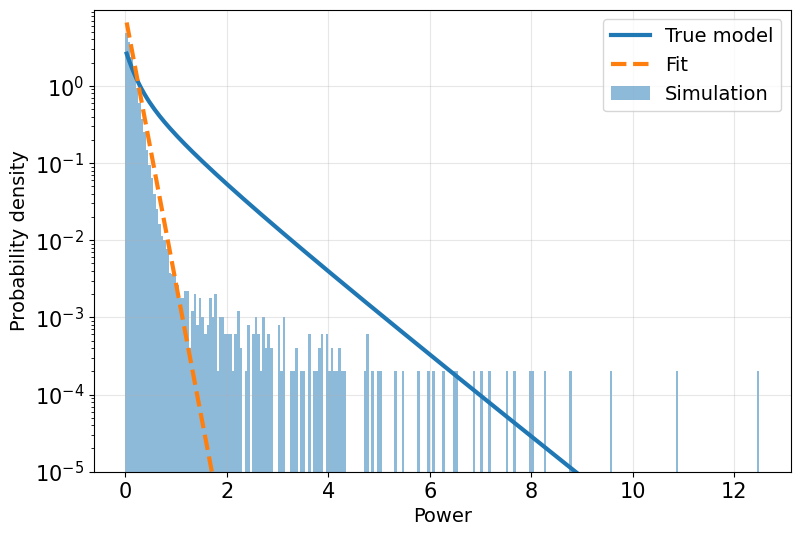

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncx2, norm
from scipy.optimize import minimize

# ==========================================================
# Generate synthetic data (unchanged)
# ==========================================================
np.random.seed(10)

num_trials = 100000
df_fixed = 2
# bg_scale = 0.5

true_mu_A = 0.1
true_sigma_A = 0.6

signal_amplitudes = np.random.normal(true_mu_A, true_sigma_A, num_trials)
signal_amplitudes = np.clip(signal_amplitudes, 0, None)

non_centralities = signal_amplitudes**2 / bg_scale

# P_nW = np.random.noncentral_chisquare(
#     df_fixed,
#     non_centralities
# ) * bg_scale

# ==========================================================
# Histogram
# ==========================================================
bin_size = 0.05

bins = np.arange(0, P_nW.max() + bin_size, bin_size)

counts, edges = np.histogram(
    P_nW,
    bins=bins,
    density=False
)

bin_centers = 0.5 * (edges[:-1] + edges[1:])

density = counts / (num_trials * bin_size)

# ==========================================================
# Integration grid
# ==========================================================
A_grid = np.linspace(0, 6, 1500)
dA = A_grid[1] - A_grid[0]

# ncx2 evaluated once
ncx2_matrix = ncx2.pdf(
    bin_centers[:, None],
    df=df_fixed,
    nc=A_grid[None, :]**2 / bg_scale,
    scale=bg_scale
)

# ==========================================================
# Forward model
# ==========================================================
def compound_pdf(mu, sigma):

    if sigma <= 0:
        return np.zeros_like(bin_centers)

    weights = norm.pdf(A_grid, mu, sigma)

    # normalize on finite grid
    weights /= np.sum(weights) * dA

    pdf = ncx2_matrix @ weights
    pdf *= dA

    # normalize output
    pdf /= np.sum(pdf) * bin_size

    return pdf


# ==========================================================
# Negative log likelihood
# ==========================================================
def loss(params):

    mu, sigma = params

    if mu < 0 or sigma < 0.05:
        return np.inf

    pdf = compound_pdf(mu, sigma)

    expected = pdf * bin_size * num_trials

    expected = np.clip(expected, 1e-12, None)

    return np.sum(expected - counts * np.log(expected))


# ==========================================================
# Fit
# ==========================================================
result = minimize(
    loss,
    x0=[1.8, 0.5],
    method='L-BFGS-B',
    bounds=[(0, 5), (0.05, 3)]
)

fit_mu, fit_sigma = result.x

print()
# print("True μ =", true_mu_A)
print("Fit  μ =", fit_mu)

print()
# print("True σ =", true_sigma_A)
print("Fit  σ =", fit_sigma)

# ==========================================================
# Plot
# ==========================================================
fit_pdf = compound_pdf(fit_mu, fit_sigma)
true_pdf = compound_pdf(true_mu_A, true_sigma_A)

plt.figure(figsize=(9,6))

plt.bar(
    edges[:-1],
    density,
    width=bin_size,
    alpha=0.5,
    align='edge',
    label='Simulation'
)

plt.plot(
    bin_centers,
    true_pdf,
    lw=3,
    label='True model'
)

plt.plot(
    bin_centers,
    fit_pdf,
    '--',
    lw=3,
    label='Fit'
)

plt.yscale("log")
plt.ylim(1e-5, density.max()*2)

plt.xlabel("Power")
plt.ylabel("Probability density")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


========== RESULTS ==========
True p  : 0.0020
Fit  p  : 0.0020

True A  : 2.0000
Fit  A  : 2.0264


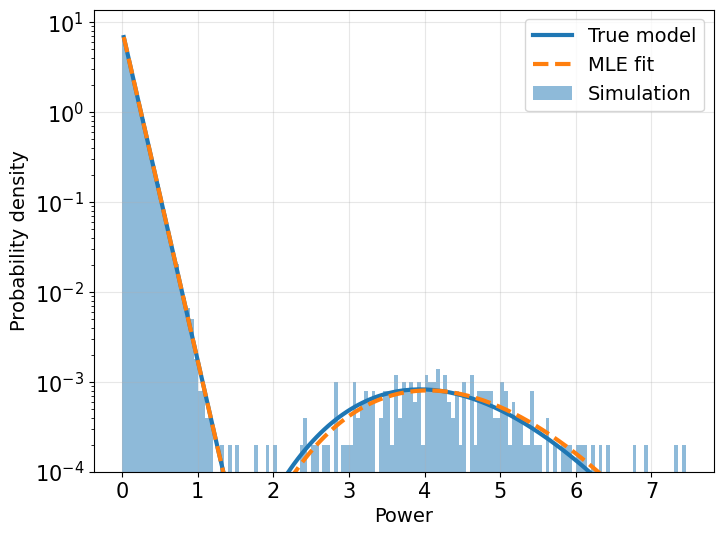

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2
from scipy.optimize import minimize

# ==========================================================
# Generate synthetic data
# ==========================================================

np.random.seed(10)

num_trials = 100000
df = 2
bg_scale = bg_scale_data  # Use the calibrated background scale from previous steps

true_p = 0.002
true_A = 2.0

has_signal = np.random.rand(num_trials) < true_p

power = np.empty(num_trials)

power[~has_signal] = (
    np.random.chisquare(df, np.sum(~has_signal))
    * bg_scale
)

power[has_signal] = (
    np.random.noncentral_chisquare(
        df,
        true_A**2/bg_scale,
        np.sum(has_signal)
    )
    * bg_scale
)

# power = P_nW

# ==========================================================
# Maximum likelihood fit
# ==========================================================

background_pdf = chi2.pdf(
    power,
    df=df,
    scale=bg_scale
)

def negative_log_likelihood(params):

    p, A = params

    if p <= 0 or p >= 1:
        return np.inf

    if A < 0:
        return np.inf

    signal_pdf = ncx2.pdf(
        power,
        df=df,
        nc=A**2/bg_scale,
        scale=bg_scale
    )

    mixture_pdf = (
        (1-p)*background_pdf
        + p*signal_pdf
    )

    mixture_pdf = np.clip(mixture_pdf, 1e-300, None)

    return -np.sum(np.log(mixture_pdf))

result = minimize(
    negative_log_likelihood,
    x0=[0.2,1.5],
    method="L-BFGS-B",
    bounds=[
        (1e-6,1-1e-6),
        (0,None)
    ]
)

fit_p, fit_A = result.x

print()
print("========== RESULTS ==========")
print(f"True p  : {true_p:.4f}")
print(f"Fit  p  : {fit_p:.4f}")
print()
print(f"True A  : {true_A:.4f}")
print(f"Fit  A  : {fit_A:.4f}")

# ==========================================================
# Plot
# ==========================================================

bin_size = 0.05

bins = np.arange(0, power.max()+bin_size, bin_size)

counts, edges = np.histogram(
    power,
    bins=bins,
    density=True
)

centers = 0.5*(edges[:-1]+edges[1:])

fit_pdf = (
    (1-fit_p)*chi2.pdf(
        centers,
        df=df,
        scale=bg_scale
    )
    + fit_p*ncx2.pdf(
        centers,
        df=df,
        nc=fit_A**2/bg_scale,
        scale=bg_scale
    )
)

true_pdf = (
    (1-true_p)*chi2.pdf(
        centers,
        df=df,
        scale=bg_scale
    )
    + true_p*ncx2.pdf(
        centers,
        df=df,
        nc=true_A**2/bg_scale,
        scale=bg_scale
    )
)

plt.figure(figsize=(8,6))

plt.bar(
    edges[:-1],
    counts,
    width=bin_size,
    alpha=0.5,
    align='edge',
    label='Simulation'
)

plt.plot(
    centers,
    true_pdf,
    lw=3,
    label='True model'
)

plt.plot(
    centers,
    fit_pdf,
    '--',
    lw=3,
    label='MLE fit'
)

plt.yscale('log')
plt.ylim(1e-4, counts.max()*2)

plt.xlabel("Power")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend()

plt.show()


========== RESULTS ==========
Fit  p  : 0.0026
Fit  A  : 1.6103
Fit  bg_scale  : 0.0592


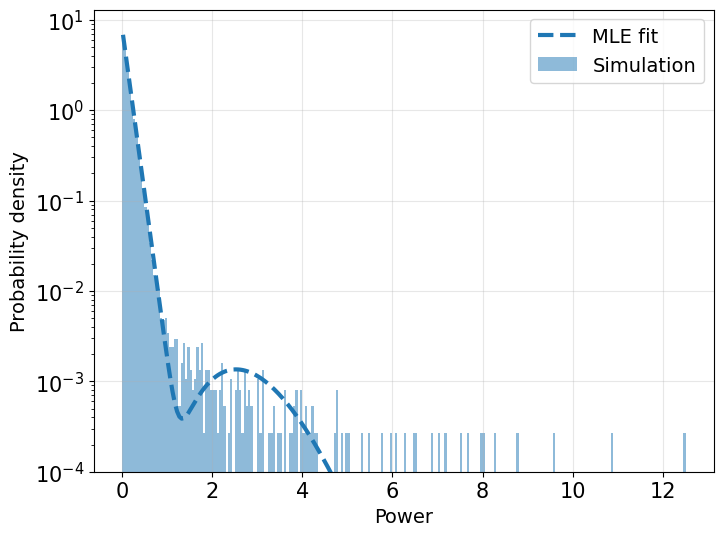

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2
from scipy.optimize import minimize

# ==========================================================
# Generate synthetic data
# ==========================================================

np.random.seed(10)

num_trials = 100000
df = 2

power = P_nW

# ==========================================================
# Maximum likelihood fit
# ==========================================================

# background_pdf = chi2.pdf(
#     power,
#     df=df,
#     scale=bg_scale_data
# )

def negative_log_likelihood(params):

    p, A, bg_scale = params

    if p <= 0 or p >= 1:
        return np.inf

    if A < 0:
        return np.inf

    
    background_pdf = chi2.pdf(
        power,
        df=df,
        scale=bg_scale
    )

    signal_pdf = ncx2.pdf(
        power,
        df=df,
        nc=A**2/bg_scale,
        scale=bg_scale
    )

    mixture_pdf = (
        (1-p)*background_pdf
        + p*signal_pdf
    )

    mixture_pdf = np.clip(mixture_pdf, 1e-300, None)

    return -np.sum(np.log(mixture_pdf))

result = minimize(
    negative_log_likelihood,
    x0=[0.01,0.4,0.05],
    method="L-BFGS-B",
    bounds=[
        (1e-6,1-1e-6),
        (0,None),
        (1e-6,None)
    ]
)

fit_p, fit_A, fit_bg_scale = result.x

print()
print("========== RESULTS ==========")
print(f"Fit  p  : {fit_p:.4f}")
print(f"Fit  A  : {fit_A:.4f}")
print(f"Fit  bg_scale  : {fit_bg_scale:.4f}")

# ==========================================================
# Plot
# ==========================================================

bin_size = 0.05

bins = np.arange(0, power.max()+bin_size, bin_size)

counts, edges = np.histogram(
    power,
    bins=bins,
    density=True
)

centers = 0.5*(edges[:-1]+edges[1:])

fit_pdf = (
    (1-fit_p)*chi2.pdf(
        centers,
        df=df,
        scale=fit_bg_scale
    )
    + fit_p*ncx2.pdf(
        centers,
        df=df,
        nc=fit_A**2/fit_bg_scale,
        scale=fit_bg_scale
    )
)


plt.figure(figsize=(8,6))

plt.bar(
    edges[:-1],
    counts,
    width=bin_size,
    alpha=0.5,
    align='edge',
    label='Simulation'
)


plt.plot(
    centers,
    fit_pdf,
    '--',
    lw=3,
    label='MLE fit'
)

plt.yscale('log')
plt.ylim(1e-4, counts.max()*2)

plt.xlabel("Power")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [142]:
from scipy.stats import poisson

def negative_log_likelihood_poisson(params):
    p, lam, bg_scale = params

    # Boundary checks
    if p <= 0 or p >= 1:
        return np.inf
    if lam < 0:
        return np.inf
    if bg_scale <= 0:
        return np.inf

    # 1. Background component
    background_pdf = chi2.pdf(power, df=df, scale=bg_scale)

    # 2. Compound Signal Component (Weighted by Poisson)
    # We sum over possible integer counts 'k'. Go up to a safe multiple of lam.
    # For initialization safety, we ensure we check at least up to k=10.
    max_k = int(max(10, lam + 5 * np.sqrt(lam)))
    k_values = np.arange(0, max_k + 1)
    
    # Calculate Poisson weights for each k
    poisson_weights = poisson.pmf(k_values, mu=lam)

    # Accumulate the signal PDF across all possible k values
    # Using broadcasting to compute efficiently across all data points
    signal_pdf = np.zeros_like(power)
    for k, weight in zip(k_values, poisson_weights):
        if weight < 1e-6: 
            continue  # Skip negligible weights to save time
        
        # Define how your non-centrality parameter scales with 'k'
        # Example: if power scales linearly with count k, nc = k / bg_scale
        # Adjust this formula based on your physical model!
        nc_k = k / bg_scale 
        
        signal_pdf += weight * ncx2.pdf(
            power,
            df=df,
            nc=nc_k,
            scale=bg_scale
        )

    # 3. Combine into the final mixture model
    mixture_pdf = (1 - p) * background_pdf + p * signal_pdf
    mixture_pdf = np.clip(mixture_pdf, 1e-300, None)

    return -np.sum(np.log(mixture_pdf))

# Update your minimizer setup:
result = minimize(
    negative_log_likelihood_poisson,
    x0=[0.01, 2.0, 0.05],  # x0[1] is now the initial guess for average Poisson count (lambda)
    method="L-BFGS-B",
    bounds=[
        (1e-6, 1-1e-6),  # p
        (0, None),       # lambda
        (1e-6, None)     # bg_scale
    ]
)

True mu = 0.3
Fit  mu = 0.602681563510468

True A0 = 10.0
Fit  A0 = 5.001290965767968


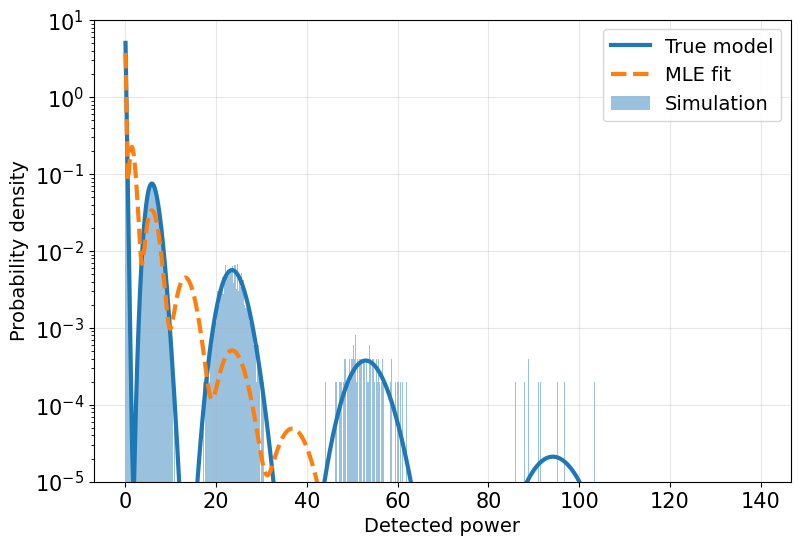

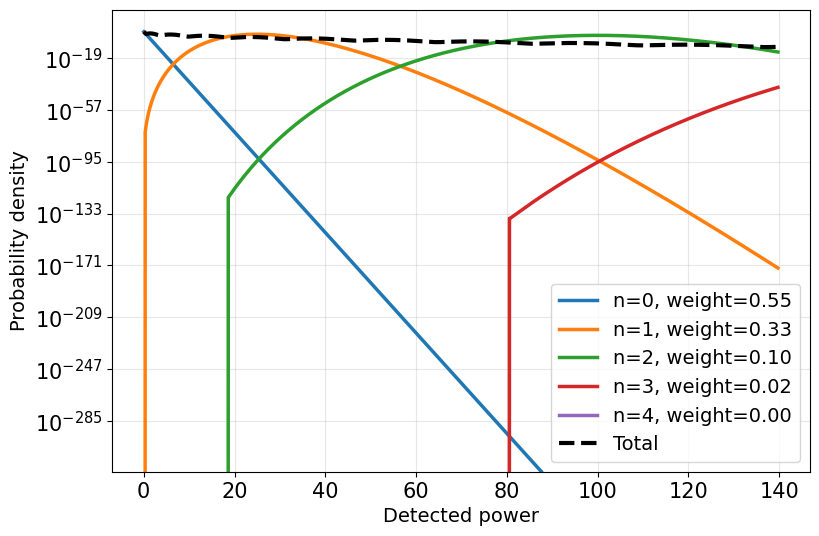

In [155]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import poisson, chi2, ncx2
from scipy.optimize import minimize


# ==========================================================
# Generate synthetic data
# ==========================================================

np.random.seed(10)

num_trials = 100000

df = 2
bg_scale = bg_scale_data  # Use the calibrated background scale from previous steps


# True signal model
true_mu = 0.3       # average photon number
true_A0 = 10.0       # amplitude per photon


# Photon number distribution
N = np.random.poisson(
    true_mu,
    num_trials
)


# Amplitude
A = N * true_A0


# Noncentrality
lambda_nc = A**2 


# Measured power
power = np.random.noncentral_chisquare(
    df,
    lambda_nc
) * bg_scale



# ==========================================================
# Likelihood model
# ==========================================================

# Photon number states included in model
n_grid = np.arange(0,15)


def poisson_signal_pdf(x, mu, A0):

    weights = poisson.pmf(
        n_grid,
        mu
    )

    pdf = np.zeros_like(x)


    for n,w in zip(n_grid,weights):

        lambda_n = (n*A0)**2

        pdf += w * ncx2.pdf(
            x,
            df=df,
            nc=lambda_n,
            scale=bg_scale
        )

    return pdf



def negative_log_likelihood(params):

    mu,A0 = params

    if mu <= 0 or A0 <= 0:
        return np.inf


    pdf = poisson_signal_pdf(
        power,
        mu,
        A0
    )

    pdf = np.clip(
        pdf,
        1e-300,
        None
    )

    return -np.sum(np.log(pdf))



# ==========================================================
# Fit
# ==========================================================

result = minimize(
    negative_log_likelihood,
    x0=[1,1],
    bounds=[
        (1e-4,10),
        (1e-4,10)
    ],
    method="L-BFGS-B"
)


fit_mu, fit_A0 = result.x


print("======================")
print("True mu =",true_mu)
print("Fit  mu =",fit_mu)

print()

print("True A0 =",true_A0)
print("Fit  A0 =",fit_A0)



# ==========================================================
# Plot histogram and fitted distribution
# ==========================================================

bin_size = 0.05

bins = np.arange(
    0,
    power.max()+bin_size,
    bin_size
)


counts,edges=np.histogram(
    power,
    bins=bins,
    density=True
)


centers = 0.5*(edges[:-1]+edges[1:])


# True distribution
true_pdf = poisson_signal_pdf(
    centers,
    true_mu,
    true_A0
)


# Fitted distribution
fit_pdf = poisson_signal_pdf(
    centers,
    fit_mu,
    fit_A0
)



plt.figure(figsize=(9,6))


plt.bar(
    edges[:-1],
    counts,
    width=bin_size,
    alpha=0.45,
    label="Simulation",
    align="edge"
)


plt.plot(
    centers,
    true_pdf,
    linewidth=3,
    label="True model"
)


plt.plot(
    centers,
    fit_pdf,
    "--",
    linewidth=3,
    label="MLE fit"
)


plt.yscale("log")

plt.xlabel("Detected power")
plt.ylabel("Probability density")

plt.ylim(
    1e-5,
    counts.max()*2
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()



# ==========================================================
# Optional: show photon-number components
# ==========================================================

plt.figure(figsize=(9,6))

for n in range(5):

    weight = poisson.pmf(
        n,
        fit_mu
    )

    component = weight * ncx2.pdf(
        centers,
        df=df,
        nc=(n*fit_A0)**2/bg_scale,
        scale=bg_scale
    )

    plt.plot(
        centers,
        component,
        label=f"n={n}, weight={weight:.2f}"
    )


plt.plot(
    centers,
    fit_pdf,
    "k--",
    linewidth=3,
    label="Total"
)


plt.yscale("log")

plt.xlabel("Detected power")
plt.ylabel("Probability density")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


========== RESULTS ==========
Fit  lambda    : 0.0998
Fit  A         : 1.5509
Fit  bg_scale  : 0.0592


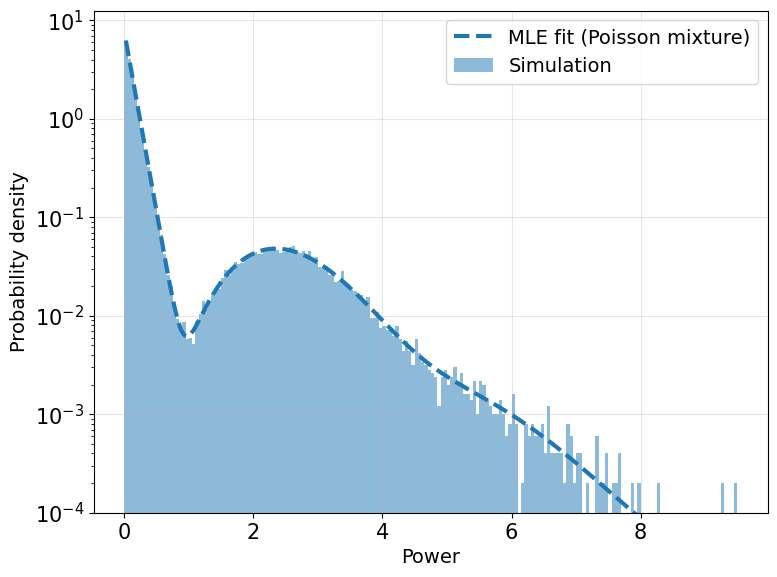

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2, poisson
from scipy.optimize import minimize

# ==========================================================
# Generate synthetic data
# ==========================================================

np.random.seed(10)

num_trials = 100000
df = 2

# --- Replace this block with your real data loading (power = P_nW) ---
# For demonstration, synthesize data from the Poisson signal-count model:
#   with n ~ Poisson(lambda), the sample is drawn from ncx2(df, nc=n*A^2/bg_scale, scale=bg_scale)
true_lambda   = 0.1
true_A        = 1.5506
true_bg_scale = bg_scale_data  # Use the calibrated background scale from previous steps

n_draws = np.random.poisson(true_lambda, size=num_trials)
power = np.empty(num_trials)
for n in np.unique(n_draws):
    mask = n_draws == n
    nc = n * true_A**2 / true_bg_scale
    power[mask] = ncx2.rvs(df, nc, scale=true_bg_scale, size=mask.sum())
# -----------------------------------------------------------------------

power = np.asarray(power)

# power = P_nW  # Use your actual measured power data here

# ==========================================================
# Poisson-weighted signal-count mixture
# ==========================================================
# Instead of a two-point (Bernoulli) mixture "signal present w.p. p, absent
# w.p. 1-p", the number of signal quanta n is Poisson-distributed with mean
# lambda. Each quantum contributes additively to the noncentrality parameter
# of the noncentral chi-square: nc(n) = n * A^2 / bg_scale.
# n = 0 automatically reduces to the pure background chi-square pdf.

def poisson_mixture_pdf(x, lam, A, bg_scale, n_max=None):
    if n_max is None:
        # cutoff where Poisson tail is negligible
        n_max = max(10, int(poisson.ppf(0.999999, lam)) + 5)

    n_values = np.arange(0, n_max + 1)
    weights = poisson.pmf(n_values, lam)          # (n_max+1,)

    x = np.atleast_1d(x)
    nc_values = n_values * A**2 / bg_scale         # (n_max+1,)

    # Broadcast: rows = n, cols = x -> shape (n_max+1, len(x))
    pdf_components = ncx2.pdf(
        x[None, :],
        df=df,
        nc=nc_values[:, None],
        scale=bg_scale
    )

    mixture_pdf = np.sum(weights[:, None] * pdf_components, axis=0)
    return mixture_pdf


def negative_log_likelihood(params):

    lam, A, bg_scale = params

    if lam <= 0:
        return np.inf
    if A < 0:
        return np.inf
    if bg_scale <= 0:
        return np.inf

    mixture_pdf = poisson_mixture_pdf(power, lam, A, bg_scale)
    mixture_pdf = np.clip(mixture_pdf, 1e-300, None)

    return -np.sum(np.log(mixture_pdf))


result = minimize(
    negative_log_likelihood,
    x0=[0.2, 2, 0.05],
    method="L-BFGS-B",
    bounds=[
        (1e-6, None),   # lambda
        (0, None),      # A
        (1e-6, None),   # bg_scale
    ]
)

fit_lambda, fit_A, fit_bg_scale = result.x

print()
print("========== RESULTS ==========")
print(f"Fit  lambda    : {fit_lambda:.4f}")
print(f"Fit  A         : {fit_A:.4f}")
print(f"Fit  bg_scale  : {fit_bg_scale:.4f}")

# ==========================================================
# Plot
# ==========================================================

bin_size = 0.05

bins = np.arange(0, power.max() + bin_size, bin_size)

counts, edges = np.histogram(
    power,
    bins=bins,
    density=True
)

centers = 0.5 * (edges[:-1] + edges[1:])

fit_pdf = poisson_mixture_pdf(centers, fit_lambda, fit_A, fit_bg_scale)

plt.figure(figsize=(8, 6))

plt.bar(
    edges[:-1],
    counts,
    width=bin_size,
    alpha=0.5,
    align='edge',
    label='Simulation'
)

plt.plot(
    centers,
    fit_pdf,
    '--',
    lw=3,
    label='MLE fit (Poisson mixture)'
)

plt.yscale('log')
plt.ylim(1e-4, counts.max() * 2)

plt.xlabel("Power")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig("/home/claude/poisson_mixture_fit.png", dpi=150)
plt.show()

Number of bins used for fitting: 1250

========== RESULTS ==========

--- gaussian ---
  p         : 0.00760
  bg_scale  : 0.05829
  mu        : 0.41939
  sigma     : 0.98523
  -logL     : 262310.36   (n_params=4)
  AIC       : 524628.72

--- boltzmann ---
  p         : 0.01175
  bg_scale  : 0.05812
  scale     : 0.64155
  -logL     : 262320.24   (n_params=3)
  AIC       : 524646.48


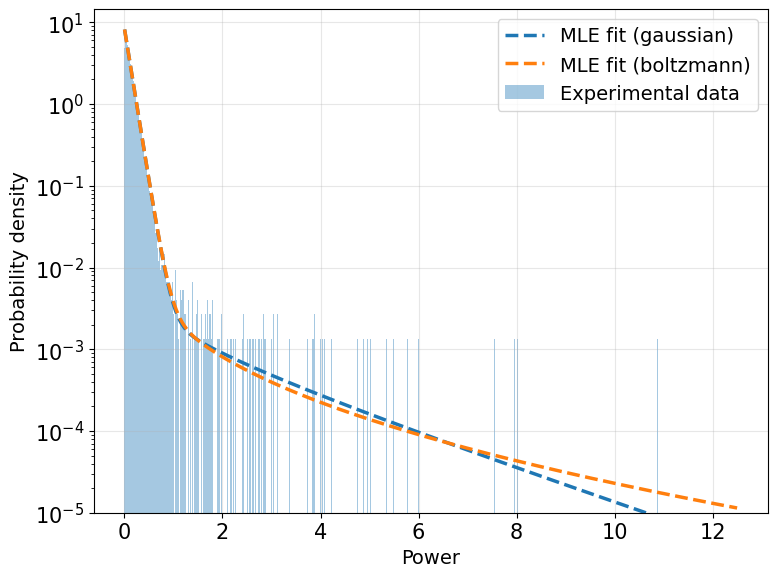

In [166]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2, norm, expon
from scipy.optimize import minimize
from numpy.polynomial.legendre import leggauss

np.random.seed(10)

num_trials = 100000
df = 2

# ============================================================
# 1) Registry of amplitude distributions
# ============================================================
# When a sample "has signal", the noncentrality parameter of the
# noncentral chi-square is nc = A^2 / bg_scale, where A is now a
# RANDOM amplitude drawn from some distribution instead of a fixed
# constant. Each entry below defines everything needed to fit and
# sample from that choice of amplitude distribution.
#
# To add a new model: give it a name, list its free parameters,
# a `make_dist` that returns a frozen scipy.stats distribution
# object (needs .pdf and .ppf), an initial guess, and bounds.

AMPLITUDE_MODELS = {

    "gaussian": {
        "param_names": ["mu", "sigma"],
        "make_dist": lambda mu, sigma: norm(loc=mu, scale=sigma),
        "x0": [0.4, 0.1],
        "bounds": [(None, None), (1e-6, None)],
    },

    "boltzmann": {
        # Boltzmann / exponential amplitude distribution: f(a) = exp(-a/scale)/scale, a >= 0
        # Heavier tail than Gaussian -> more probability mass at large amplitudes,
        # which is exactly what you need to explain rare-but-large power outliers
        # when p (probability of signal) is small.
        "param_names": ["scale"],
        "make_dist": lambda scale: expon(scale=scale),
        "x0": [0.5],
        "bounds": [(1e-6, None)],
    },

    # Example of how easy it is to add another candidate:
    # "rayleigh": {
    #     "param_names": ["scale"],
    #     "make_dist": lambda scale: rayleigh(scale=scale),
    #     "x0": [0.3],
    #     "bounds": [(1e-6, None)],
    # },
}

# ============================================================
# 2) Numerical marginalization: ncx2 signal pdf averaged over
#    the amplitude distribution, via Gauss-Legendre quadrature
# ============================================================

N_QUAD = 48
_gl_nodes, _gl_weights = leggauss(N_QUAD)  # nodes/weights on [-1, 1]


def _quadrature_grid(dist, lo_q=1e-6, hi_q=1 - 1e-6, fallback_span=50.0):
    """Map Gauss-Legendre nodes onto the effective support of `dist`."""
    lo = dist.ppf(lo_q)
    hi = dist.ppf(hi_q)

    if not np.isfinite(lo):
        lo = -fallback_span
    if not np.isfinite(hi):
        hi = fallback_span

    # nodes/weights rescaled from [-1,1] to [lo,hi]
    a_nodes = 0.5 * (hi - lo) * _gl_nodes + 0.5 * (hi + lo)
    a_weights = 0.5 * (hi - lo) * _gl_weights
    return a_nodes, a_weights


def signal_pdf_marginal(x, dist, bg_scale, df):
    """
    signal_pdf(x) = integral over a of  ncx2.pdf(x, df, nc=a^2/bg_scale, scale=bg_scale) * f(a) da
    computed via Gauss-Legendre quadrature.
    """
    a_nodes, a_weights = _quadrature_grid(dist)

    f_a = dist.pdf(a_nodes)                 # (n_quad,)
    nc_nodes = a_nodes**2 / bg_scale         # (n_quad,)

    # broadcast over (n_quad, n_data)
    pdf_components = ncx2.pdf(
        x[None, :],
        df=df,
        nc=nc_nodes[:, None],
        scale=bg_scale
    )

    integrand_weights = (a_weights * f_a)[:, None]   # (n_quad, 1)
    return np.sum(integrand_weights * pdf_components, axis=0)


# ============================================================
# 3) Generic BINNED negative log-likelihood builder
# ============================================================
# With ~1e5 samples and a quadrature integral evaluated at every point,
# unbinned MLE is far too slow to optimize (each likelihood evaluation
# broadcasts n_quad x n_data). Binned MLE evaluates the model only at
# bin centers (~100s of points instead of ~1e5), which is a >100x
# speedup and is standard practice for this data volume. Using the
# same fine bins for fitting and plotting keeps everything consistent,
# and fine bins still preserve the tail resolution that matters for
# rare, high-power signal events.

def make_binned_negative_log_likelihood(bin_centers, bin_counts, bin_width, df, model_name):
    model = AMPLITUDE_MODELS[model_name]

    def negative_log_likelihood(params):
        p, bg_scale = params[0], params[1]
        dist_params = params[2:]

        if p <= 0 or p >= 1:
            return np.inf
        if bg_scale <= 0:
            return np.inf

        try:
            dist = model["make_dist"](*dist_params)
        except Exception:
            return np.inf

        background_pdf = chi2.pdf(bin_centers, df=df, scale=bg_scale)
        signal_pdf = signal_pdf_marginal(bin_centers, dist, bg_scale, df)

        mixture_pdf = (1 - p) * background_pdf + p * signal_pdf
        bin_prob = np.clip(mixture_pdf * bin_width, 1e-300, None)

        return -np.sum(bin_counts * np.log(bin_prob))

    return negative_log_likelihood


def fit_model(bin_centers, bin_counts, bin_width, df, model_name, p0=0.02, bg_scale0=0.05):
    model = AMPLITUDE_MODELS[model_name]

    x0 = [p0, bg_scale0] + list(model["x0"])
    bounds = [(1e-6, 1 - 1e-6), (1e-6, None)] + list(model["bounds"])

    nll = make_binned_negative_log_likelihood(bin_centers, bin_counts, bin_width, df, model_name)

    result = minimize(
        nll,
        x0=x0,
        method="L-BFGS-B",
        bounds=bounds
    )

    fit_p, fit_bg_scale = result.x[0], result.x[1]
    fit_dist_params = dict(zip(model["param_names"], result.x[2:]))

    return {
        "model_name": model_name,
        "p": fit_p,
        "bg_scale": fit_bg_scale,
        "dist_params": fit_dist_params,
        "nll": result.fun,
        "n_params": len(x0),
        "raw_result": result,
    }


def fitted_pdf(x, df, fit):
    model = AMPLITUDE_MODELS[fit["model_name"]]
    dist = model["make_dist"](*[fit["dist_params"][name] for name in model["param_names"]])

    background_pdf = chi2.pdf(x, df=df, scale=fit["bg_scale"])
    signal_pdf = signal_pdf_marginal(x, dist, fit["bg_scale"], df)

    return (1 - fit["p"]) * background_pdf + fit["p"] * signal_pdf


# ============================================================
# 4) Generate synthetic data
# ============================================================
# Low signal probability, exponential/Boltzmann-distributed amplitude,
# to mirror the scenario you described: rare events, heavy tail.

true_p        = 0.01176
true_scale    = 0.64103       # Boltzmann/exponential amplitude scale
true_bg_scale = 0.05812

# --- Replace this block with your real data loading (power = P_nW) ---
has_signal = np.random.rand(num_trials) < true_p

power = np.empty(num_trials)
n_bg = (~has_signal).sum()
n_sig = has_signal.sum()

power[~has_signal] = chi2.rvs(df, scale=true_bg_scale, size=n_bg)

true_amplitudes = expon.rvs(scale=true_scale, size=n_sig)
power[has_signal] = ncx2.rvs(
    df,
    true_amplitudes**2 / true_bg_scale,
    scale=true_bg_scale
)
# -----------------------------------------------------------------------

power = np.asarray(power)
data_label = "Simulation (Boltzmann)"
power = P_nW
data_label = "Experimental data"
# ============================================================
# 5) Bin the data once (used for BOTH fitting and plotting)
# ============================================================

bin_size = 0.01
bin_edges = np.arange(0, power.max() + bin_size, bin_size)
bin_counts, _ = np.histogram(power, bins=bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

print(f"Number of bins used for fitting: {len(bin_centers)}")

# ============================================================
# 6) Fit multiple candidate models and compare
# ============================================================

MODELS_TO_COMPARE = ["gaussian", "boltzmann"]

fits = {}
for name in MODELS_TO_COMPARE:
    fits[name] = fit_model(bin_centers, bin_counts, bin_size, df, name, p0 =0.01)

print()
print("========== RESULTS ==========")
for name, fit in fits.items():
    print(f"\n--- {name} ---")
    print(f"  p         : {fit['p']:.5f}")
    print(f"  bg_scale  : {fit['bg_scale']:.5f}")
    for pname, pval in fit["dist_params"].items():
        print(f"  {pname:<9} : {pval:.5f}")
    print(f"  -logL     : {fit['nll']:.2f}   (n_params={fit['n_params']})")
    # AIC for a quick, honest comparison across models with different #params
    aic = 2 * fit["n_params"] + 2 * fit["nll"]
    print(f"  AIC       : {aic:.2f}")

# ============================================================
# 7) Plot (reusing the same bins used for fitting)
# ============================================================

density = bin_counts / (bin_counts.sum() * bin_size)

plt.figure(figsize=(8, 6))

plt.bar(
    bin_edges[:-1],
    density,
    width=bin_size,
    alpha=0.4,
    align='edge',
    label=data_label
)

for name, fit in fits.items():
    curve = fitted_pdf(bin_centers, df, fit)
    plt.plot(bin_centers, curve, '--', lw=2.5, label=f"MLE fit ({name})")

plt.yscale('log')
plt.ylim(1e-5, density.max() * 2)

plt.xlabel("Power")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig("/home/claude/pluggable_signal_models_fit.png", dpi=150)
plt.show()

Number of bins used for fitting: 1250

========== RESULTS ==========

--- gaussian ---
  p         : 0.00629
  bg_scale  : 0.05839
  mu        : 0.87885
  sigma     : 0.76561
  -logL     : 262309.50   (n_params=4)
  AIC       : 524627.00

--- boltzmann ---
  p         : 0.01176
  bg_scale  : 0.05812
  scale     : 0.64098
  -logL     : 262320.24   (n_params=3)
  AIC       : 524646.48


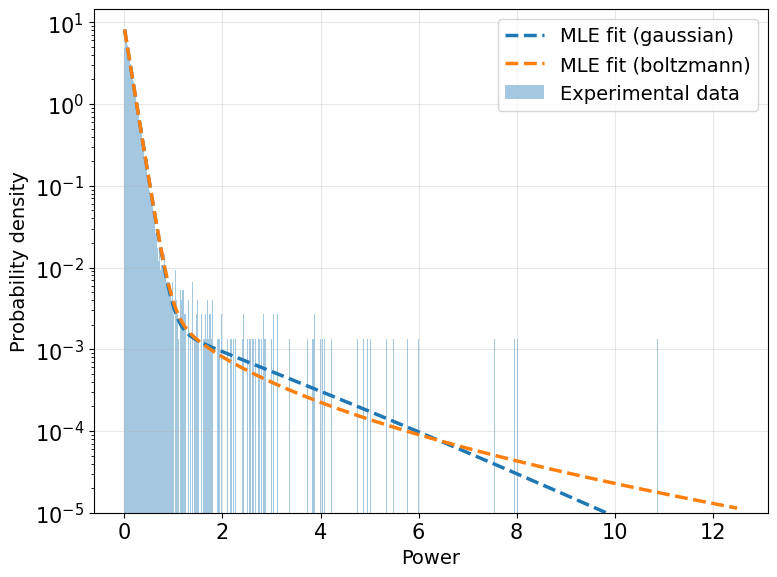

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, ncx2, norm, expon
from scipy.optimize import minimize
from numpy.polynomial.legendre import leggauss

np.random.seed(10)

num_trials = 100000
df = 2

# ============================================================
# 1) Registry of amplitude distributions
# ============================================================
# When a sample "has signal", the noncentrality parameter of the
# noncentral chi-square is nc = A^2 / bg_scale, where A is now a
# RANDOM amplitude drawn from some distribution instead of a fixed
# constant. Each entry below defines everything needed to fit and
# sample from that choice of amplitude distribution.
#
# To add a new model: give it a name, list its free parameters,
# a `make_dist` that returns a frozen scipy.stats distribution
# object (needs .pdf and .ppf), an initial guess, and bounds.

AMPLITUDE_MODELS = {

    "gaussian": {
        "param_names": ["mu", "sigma"],
        "make_dist": lambda mu, sigma: norm(loc=mu, scale=sigma),
        "x0": [0.4, 0.1],
        "bounds": [(None, None), (1e-6, None)],
    },

    "boltzmann": {
        # Boltzmann / exponential amplitude distribution: f(a) = exp(-a/scale)/scale, a >= 0
        # Heavier tail than Gaussian -> more probability mass at large amplitudes,
        # which is exactly what you need to explain rare-but-large power outliers
        # when p (probability of signal) is small.
        "param_names": ["scale"],
        "make_dist": lambda scale: expon(scale=scale),
        "x0": [0.5],
        "bounds": [(1e-6, None)],
    },

    # Example of how easy it is to add another candidate:
    # "rayleigh": {
    #     "param_names": ["scale"],
    #     "make_dist": lambda scale: rayleigh(scale=scale),
    #     "x0": [0.3],
    #     "bounds": [(1e-6, None)],
    # },
}

# ============================================================
# 2) Numerical marginalization: ncx2 signal pdf averaged over
#    the amplitude distribution, via Gauss-Legendre quadrature
# ============================================================

N_QUAD = 48
_gl_nodes, _gl_weights = leggauss(N_QUAD)  # nodes/weights on [-1, 1]


def _quadrature_grid(dist, lo_q=1e-6, hi_q=1 - 1e-6, fallback_span=50.0):
    """Map Gauss-Legendre nodes onto the effective support of `dist`."""
    lo = dist.ppf(lo_q)
    hi = dist.ppf(hi_q)

    if not np.isfinite(lo):
        lo = -fallback_span
    if not np.isfinite(hi):
        hi = fallback_span

    # nodes/weights rescaled from [-1,1] to [lo,hi]
    a_nodes = 0.5 * (hi - lo) * _gl_nodes + 0.5 * (hi + lo)
    a_weights = 0.5 * (hi - lo) * _gl_weights
    return a_nodes, a_weights


def signal_pdf_marginal(x, dist, bg_scale, df):
    """
    signal_pdf(x) = integral over a of  ncx2.pdf(x, df, nc=a^2/bg_scale, scale=bg_scale) * f(a) da
    computed via Gauss-Legendre quadrature.
    """
    a_nodes, a_weights = _quadrature_grid(dist)

    f_a = dist.pdf(a_nodes)                 # (n_quad,)
    nc_nodes = a_nodes**2 / bg_scale         # (n_quad,)

    # broadcast over (n_quad, n_data)
    pdf_components = ncx2.pdf(
        x[None, :],
        df=df,
        nc=nc_nodes[:, None],
        scale=bg_scale
    )

    integrand_weights = (a_weights * f_a)[:, None]   # (n_quad, 1)
    return np.sum(integrand_weights * pdf_components, axis=0)


# ============================================================
# 3) Generic BINNED negative log-likelihood builder
# ============================================================
# With ~1e5 samples and a quadrature integral evaluated at every point,
# unbinned MLE is far too slow to optimize (each likelihood evaluation
# broadcasts n_quad x n_data). Binned MLE evaluates the model only at
# bin centers (~100s of points instead of ~1e5), which is a >100x
# speedup and is standard practice for this data volume. Using the
# same fine bins for fitting and plotting keeps everything consistent,
# and fine bins still preserve the tail resolution that matters for
# rare, high-power signal events.

def make_binned_negative_log_likelihood(bin_centers, bin_counts, bin_width, df, model_name):
    model = AMPLITUDE_MODELS[model_name]

    def negative_log_likelihood(params):
        p, bg_scale = params[0], params[1]
        dist_params = params[2:]

        if p <= 0 or p >= 1:
            return np.inf
        if bg_scale <= 0:
            return np.inf

        try:
            dist = model["make_dist"](*dist_params)
        except Exception:
            return np.inf

        background_pdf = chi2.pdf(bin_centers, df=df, scale=bg_scale)
        signal_pdf = signal_pdf_marginal(bin_centers, dist, bg_scale, df)

        mixture_pdf = (1 - p) * background_pdf + p * signal_pdf
        bin_prob = np.clip(mixture_pdf * bin_width, 1e-300, None)

        return -np.sum(bin_counts * np.log(bin_prob))

    return negative_log_likelihood


def fit_model(bin_centers, bin_counts, bin_width, df, model_name, p0=0.02, bg_scale0=0.05):
    model = AMPLITUDE_MODELS[model_name]

    x0 = [p0, bg_scale0] + list(model["x0"])
    bounds = [(1e-6, 1 - 1e-6), (1e-6, None)] + list(model["bounds"])

    nll = make_binned_negative_log_likelihood(bin_centers, bin_counts, bin_width, df, model_name)

    result = minimize(
        nll,
        x0=x0,
        method="L-BFGS-B",
        bounds=bounds
    )

    fit_p, fit_bg_scale = result.x[0], result.x[1]
    fit_dist_params = dict(zip(model["param_names"], result.x[2:]))

    return {
        "model_name": model_name,
        "p": fit_p,
        "bg_scale": fit_bg_scale,
        "dist_params": fit_dist_params,
        "nll": result.fun,
        "n_params": len(x0),
        "raw_result": result,
    }


def fitted_pdf(x, df, fit):
    model = AMPLITUDE_MODELS[fit["model_name"]]
    dist = model["make_dist"](*[fit["dist_params"][name] for name in model["param_names"]])

    background_pdf = chi2.pdf(x, df=df, scale=fit["bg_scale"])
    signal_pdf = signal_pdf_marginal(x, dist, fit["bg_scale"], df)

    return (1 - fit["p"]) * background_pdf + fit["p"] * signal_pdf


# ============================================================
# 4) Generate synthetic data
# ============================================================
# Low signal probability, exponential/Boltzmann-distributed amplitude,
# to mirror the scenario you described: rare events, heavy tail.

true_p        = 0.01176
true_scale    = 0.64103       # Boltzmann/exponential amplitude scale
true_bg_scale = 0.05812

# --- Replace this block with your real data loading (power = P_nW) ---
has_signal = np.random.rand(num_trials) < true_p

power = np.empty(num_trials)
n_bg = (~has_signal).sum()
n_sig = has_signal.sum()

power[~has_signal] = chi2.rvs(df, scale=true_bg_scale, size=n_bg)

true_amplitudes = expon.rvs(scale=true_scale, size=n_sig)
power[has_signal] = ncx2.rvs(
    df,
    true_amplitudes**2 / true_bg_scale,
    scale=true_bg_scale
)
# -----------------------------------------------------------------------

power = np.asarray(power)
data_label = "Simulation (Boltzmann)"
power = P_nW
data_label = "Experimental data"
# ============================================================
# 5) Bin the data once (used for BOTH fitting and plotting)
# ============================================================

bin_size = 0.01
bin_edges = np.arange(0, power.max() + bin_size, bin_size)
bin_counts, _ = np.histogram(power, bins=bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

print(f"Number of bins used for fitting: {len(bin_centers)}")

# ============================================================
# 6) Fit multiple candidate models and compare
# ============================================================

MODELS_TO_COMPARE = ["gaussian", "boltzmann"]

fits = {}
for name in MODELS_TO_COMPARE:
    fits[name] = fit_model(bin_centers, bin_counts, bin_size, df, name, p0 =0.38)

print()
print("========== RESULTS ==========")
for name, fit in fits.items():
    print(f"\n--- {name} ---")
    print(f"  p         : {fit['p']:.5f}")
    print(f"  bg_scale  : {fit['bg_scale']:.5f}")
    for pname, pval in fit["dist_params"].items():
        print(f"  {pname:<9} : {pval:.5f}")
    print(f"  -logL     : {fit['nll']:.2f}   (n_params={fit['n_params']})")
    # AIC for a quick, honest comparison across models with different #params
    aic = 2 * fit["n_params"] + 2 * fit["nll"]
    print(f"  AIC       : {aic:.2f}")

# ============================================================
# 7) Plot (reusing the same bins used for fitting)
# ============================================================

density = bin_counts / (bin_counts.sum() * bin_size)

plt.figure(figsize=(8, 6))

plt.bar(
    bin_edges[:-1],
    density,
    width=bin_size,
    alpha=0.4,
    align='edge',
    label=data_label
)

for name, fit in fits.items():
    curve = fitted_pdf(bin_centers, df, fit)
    plt.plot(bin_centers, curve, '--', lw=2.5, label=f"MLE fit ({name})")

plt.yscale('log')
plt.ylim(1e-5, density.max() * 2)

plt.xlabel("Power")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig("/home/claude/pluggable_signal_models_fit.png", dpi=150)
plt.show()

In [234]:
def convert_dict_to_dataframe(input_dict):
    # Regex pattern to capture the values and determine if it's data or time
    pattern = r"dBm(?P<dBm>[-+]?\d*\.\d+|\d+)_average(?P<avg>\d+)_repetition(?P<rep>\d+)_(?P<type>data|time)"
    
    # Dictionary to temporarily store grouped records
    grouped_records = {}
    
    for key, val_array in input_dict.items():
        match = re.match(pattern, key)
        if match:
            # print('here')
            metadata = match.groupdict()
            # Convert extracted strings to their proper types
            dBm_val = float(metadata['dBm'])
            avg_val = int(metadata['avg'])
            rep_val = int(metadata['rep'])
            data_type = metadata['type']  # This will be either 'data' or 'time'
            
            # Unique identifier for this specific combination
            combo_key = (dBm_val, avg_val, rep_val)
            
            # Initialize the row structure if we haven't seen this combination yet
            if combo_key not in grouped_records:
                grouped_records[combo_key] = {
                    'dBm': dBm_val,
                    'avg': avg_val,
                    'rep': rep_val,
                    'data': None,
                    'time': None
                }
            
            # Assign the numpy array to the correct column ('data' or 'time')
            grouped_records[combo_key][data_type] = val_array

    # Convert the dictionary values into a list of rows and create the DataFrame
    df = pd.DataFrame(list(grouped_records.values()))
    
    # Optional: Reorder columns explicitly to match your request
    # df = df[['dBm', 'avg', 'rep', 'data', 'time']]
    
    return df
data_dir = '/home/electron/data/experiment_07092026'
data_dict = load_h5_data('RFPowerConstSweepTipSwitched_14-24-17.h5', base=data_dir) #load_latest_data() #
# print(data_dict)
df = convert_dict_to_dataframe(data_dict)

Number of bins used for fitting: 537

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.03957
  mu        : -0.00073
  sigma     : 0.09979
  -logL     : 576177.54   (n_params=4)
  AIC       : 1152363.07

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.03957
  scale     : 0.39537
  -logL     : 576177.55   (n_params=3)
  AIC       : 1152361.09


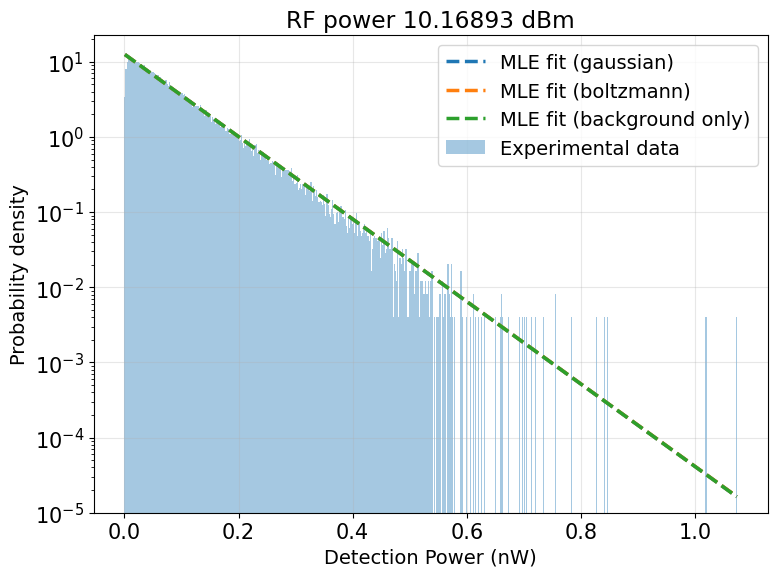

Number of bins used for fitting: 581

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.04282
  mu        : 0.04942
  sigma     : 0.09962
  -logL     : 582307.05   (n_params=4)
  AIC       : 1164622.09

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.04282
  scale     : 0.42775
  -logL     : 582307.05   (n_params=3)
  AIC       : 1164620.10


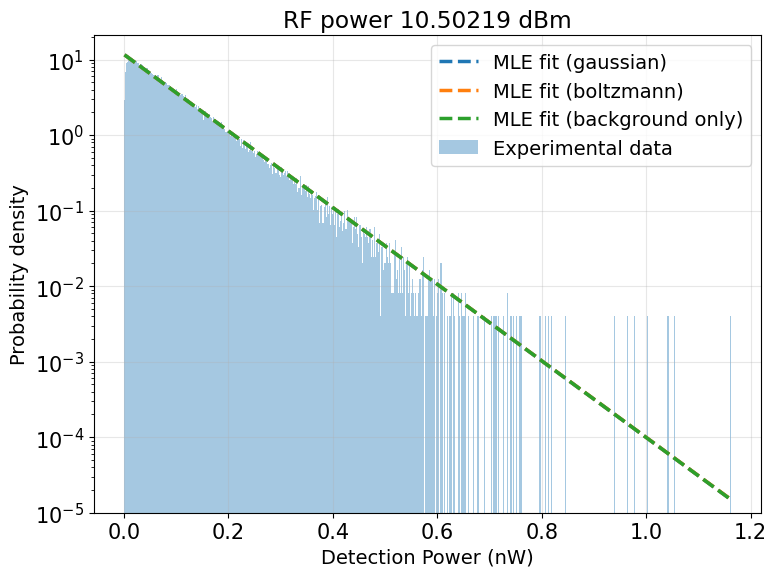

Number of bins used for fitting: 539

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.04525
  mu        : 0.05838
  sigma     : 0.09961
  -logL     : 585454.92   (n_params=4)
  AIC       : 1170917.84

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.04525
  scale     : 0.45193
  -logL     : 585454.93   (n_params=3)
  AIC       : 1170915.87


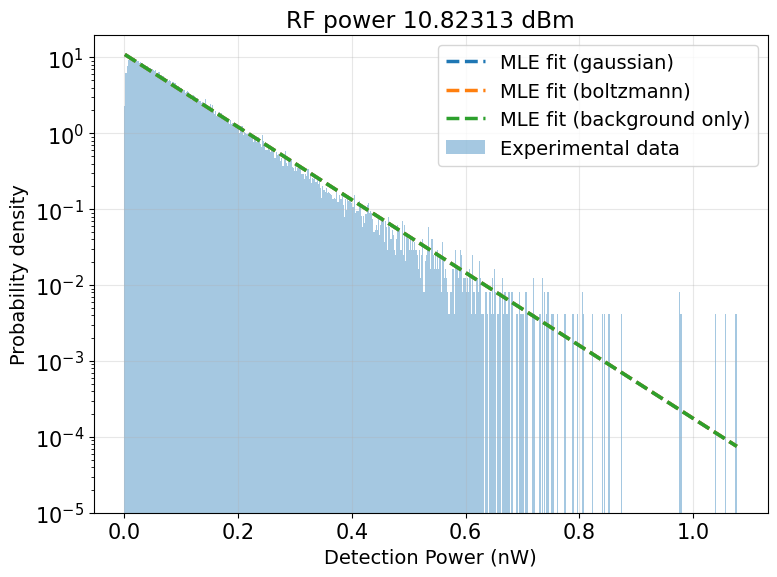

Number of bins used for fitting: 585

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.04902
  mu        : 0.21618
  sigma     : 0.09957
  -logL     : 598868.46   (n_params=4)
  AIC       : 1197744.92

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.04902
  scale     : 0.48965
  -logL     : 598868.48   (n_params=3)
  AIC       : 1197742.95


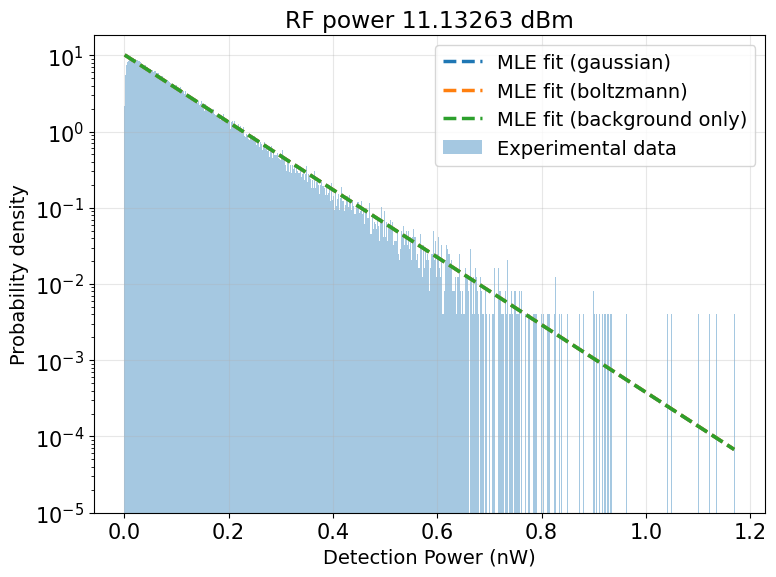

Number of bins used for fitting: 491

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.05166
  mu        : 0.39999
  sigma     : 0.10000
  -logL     : 605295.50   (n_params=4)
  AIC       : 1210598.99

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.05166
  scale     : 0.50000
  -logL     : 605295.52   (n_params=3)
  AIC       : 1210597.03


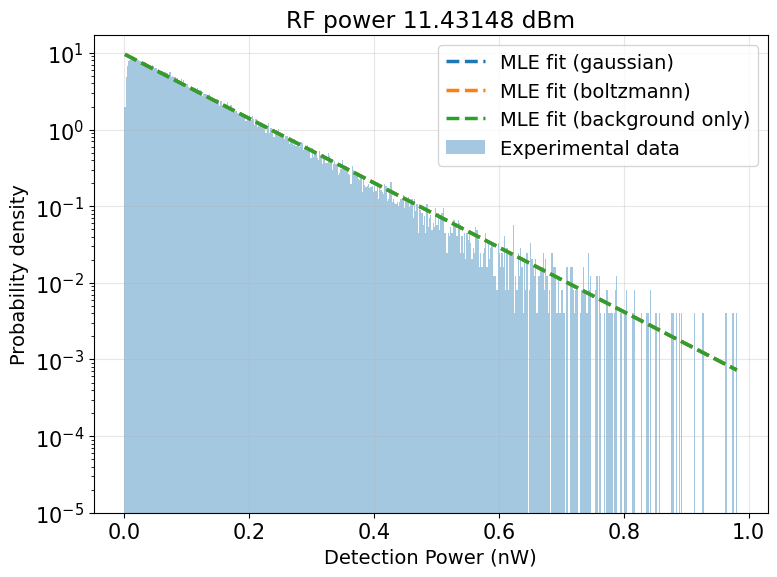

Number of bins used for fitting: 724

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.05511
  mu        : 0.39999
  sigma     : 0.10000
  -logL     : 613204.54   (n_params=4)
  AIC       : 1226417.08

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.05511
  scale     : 0.50000
  -logL     : 613204.54   (n_params=3)
  AIC       : 1226415.08


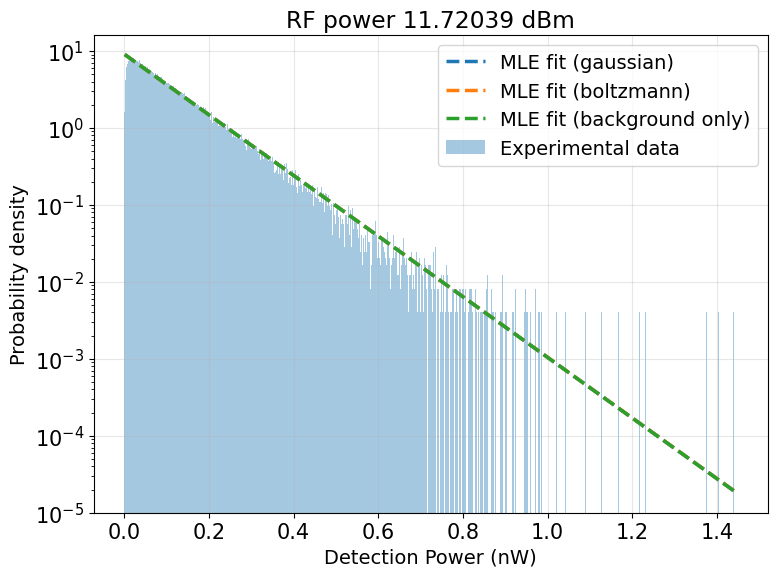

Number of bins used for fitting: 1448

========== RESULTS ==========

--- gaussian ---
  p         : 0.00038
  bg_scale  : 0.05864
  mu        : 0.40001
  sigma     : 0.10003
  -logL     : 620896.70   (n_params=4)
  AIC       : 1241801.39

--- boltzmann ---
  p         : 0.00014
  bg_scale  : 0.05864
  scale     : 0.50000
  -logL     : 620881.35   (n_params=3)
  AIC       : 1241768.69


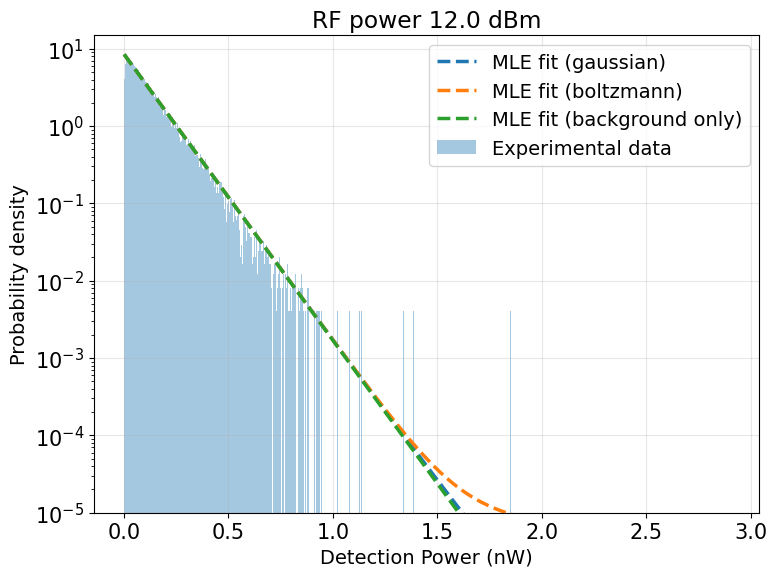

Number of bins used for fitting: 227

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.01924
  mu        : -0.52141
  sigma     : 0.27480
  -logL     : 490304.29   (n_params=4)
  AIC       : 980616.57

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.01924
  scale     : 0.19216
  -logL     : 490304.24   (n_params=3)
  AIC       : 980614.49


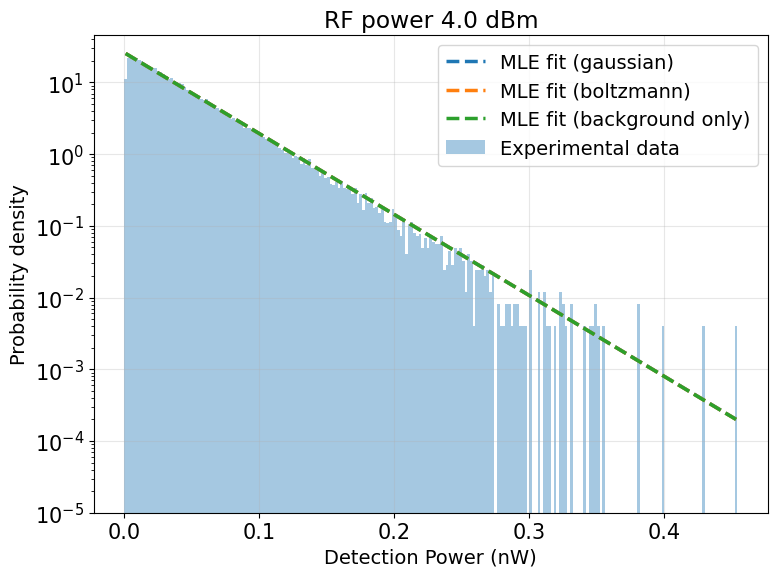

Number of bins used for fitting: 193

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.01910
  mu        : -0.52262
  sigma     : 0.27648
  -logL     : 492415.32   (n_params=4)
  AIC       : 984838.65

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.01910
  scale     : 0.19081
  -logL     : 492415.28   (n_params=3)
  AIC       : 984836.55


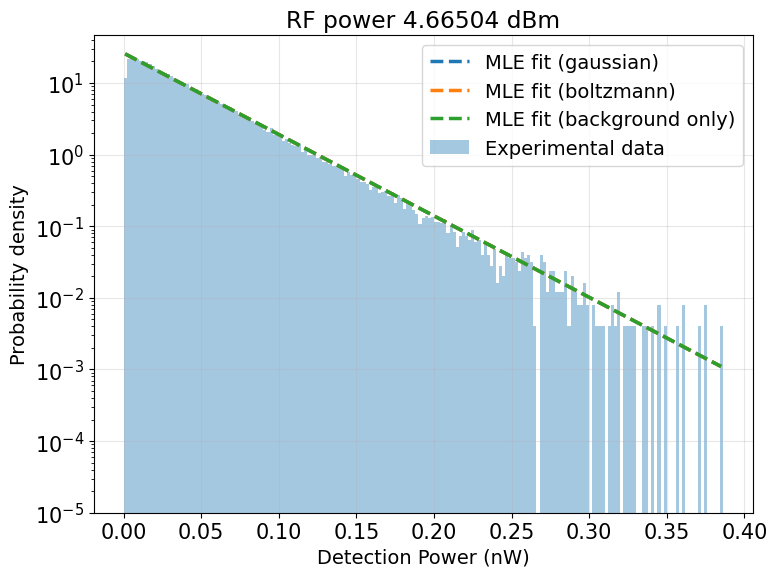

Number of bins used for fitting: 211

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.02009
  mu        : -0.55264
  sigma     : 0.27078
  -logL     : 495672.91   (n_params=4)
  AIC       : 991353.82

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.02009
  scale     : 0.20010
  -logL     : 495672.86   (n_params=3)
  AIC       : 991351.73


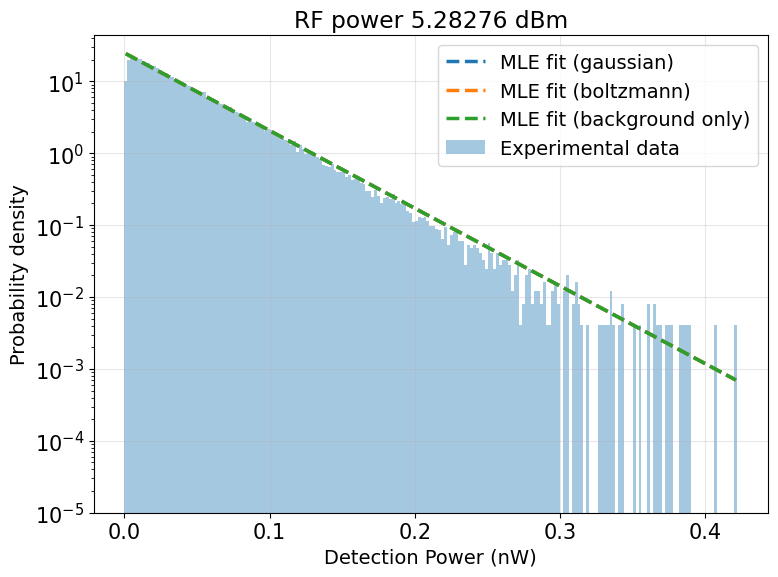

Number of bins used for fitting: 213

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.02149
  mu        : -0.44379
  sigma     : 0.23574
  -logL     : 504030.11   (n_params=4)
  AIC       : 1008068.21

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.02149
  scale     : 0.21464
  -logL     : 504030.08   (n_params=3)
  AIC       : 1008066.16


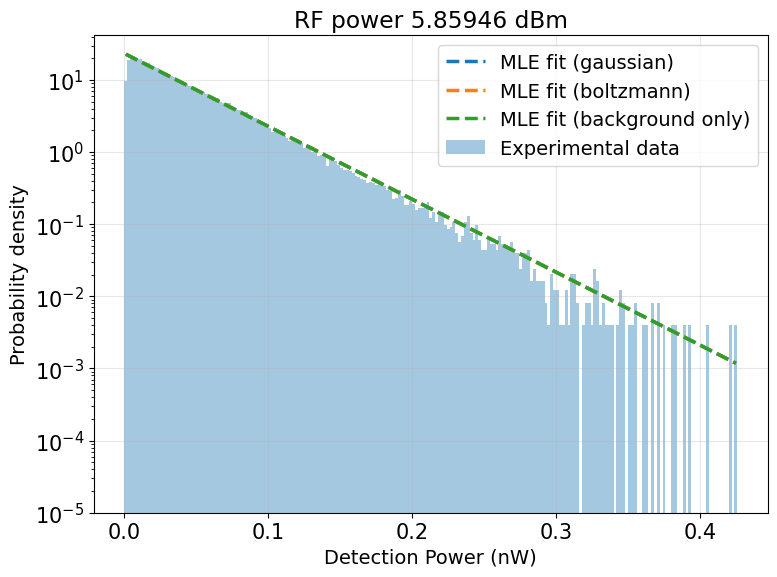

Number of bins used for fitting: 238

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.02350
  mu        : -0.11331
  sigma     : 0.16933
  -logL     : 515089.26   (n_params=4)
  AIC       : 1030186.52

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.02350
  scale     : 0.22259
  -logL     : 515089.27   (n_params=3)
  AIC       : 1030184.54


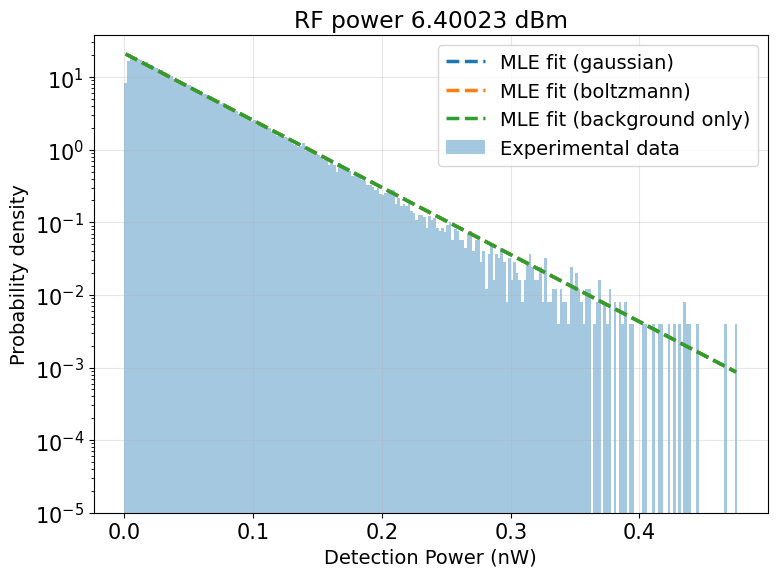

Number of bins used for fitting: 329

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.02624
  mu        : 0.03659
  sigma     : 0.13658
  -logL     : 522353.79   (n_params=4)
  AIC       : 1044715.58

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.02624
  scale     : 0.26208
  -logL     : 522353.80   (n_params=3)
  AIC       : 1044713.59


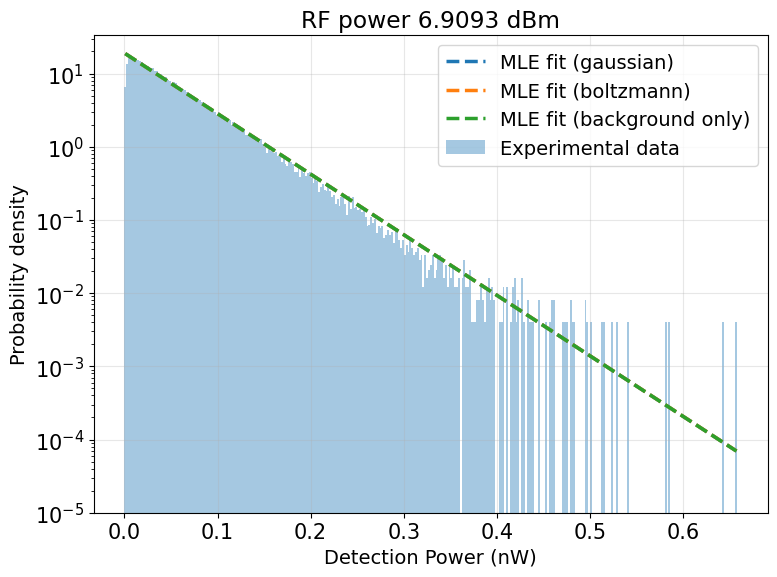

Number of bins used for fitting: 265

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.02818
  mu        : 0.00360
  sigma     : 0.12860
  -logL     : 531112.66   (n_params=4)
  AIC       : 1062233.31

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.02818
  scale     : 0.28149
  -logL     : 531112.67   (n_params=3)
  AIC       : 1062231.34


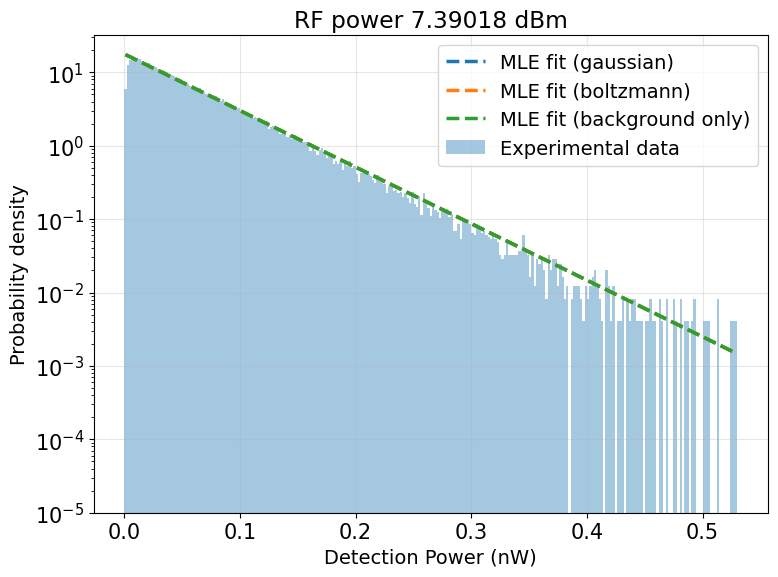

Number of bins used for fitting: 329

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.02999
  mu        : 0.06988
  sigma     : 0.11572
  -logL     : 542039.97   (n_params=4)
  AIC       : 1084087.94

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.02999
  scale     : 0.29962
  -logL     : 542039.99   (n_params=3)
  AIC       : 1084085.97


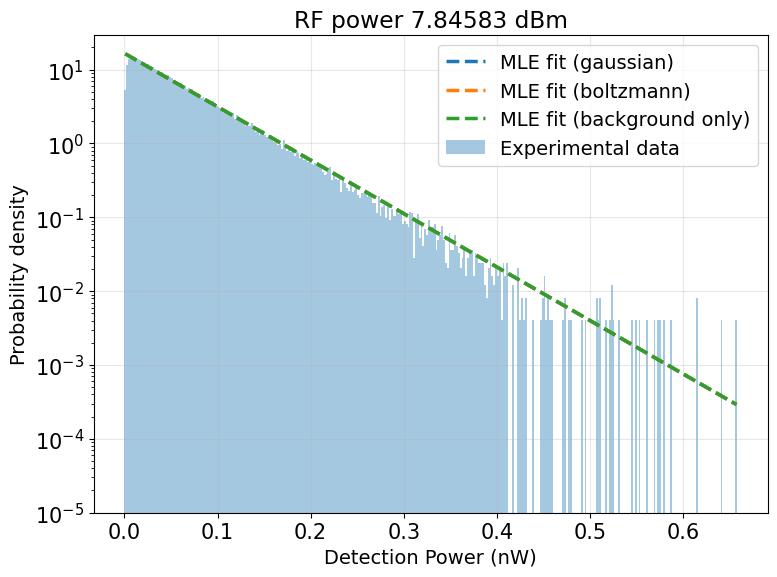

Number of bins used for fitting: 346

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.03042
  mu        : -0.00236
  sigma     : 0.11690
  -logL     : 543799.96   (n_params=4)
  AIC       : 1087607.91

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.03042
  scale     : 0.30383
  -logL     : 543799.97   (n_params=3)
  AIC       : 1087605.94


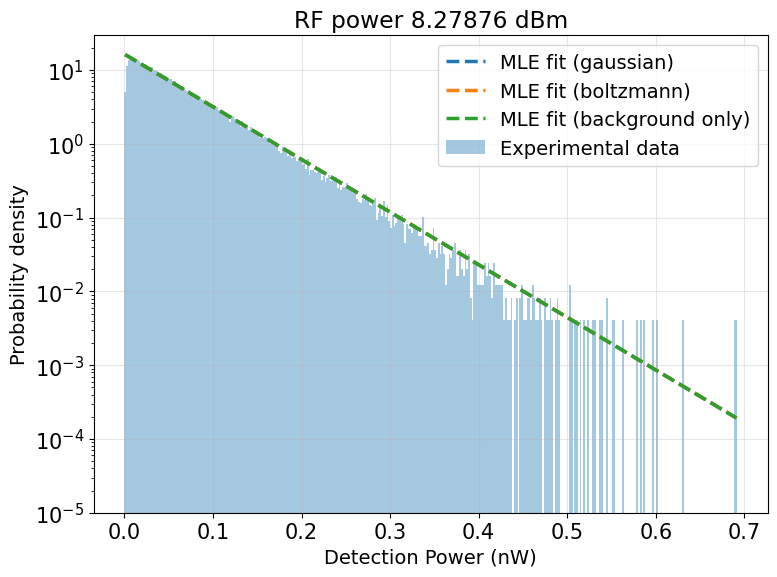

Number of bins used for fitting: 422

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.03084
  mu        : 0.05957
  sigma     : 0.11307
  -logL     : 538825.84   (n_params=4)
  AIC       : 1077659.68

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.03084
  scale     : 0.30774
  -logL     : 538825.85   (n_params=3)
  AIC       : 1077657.69


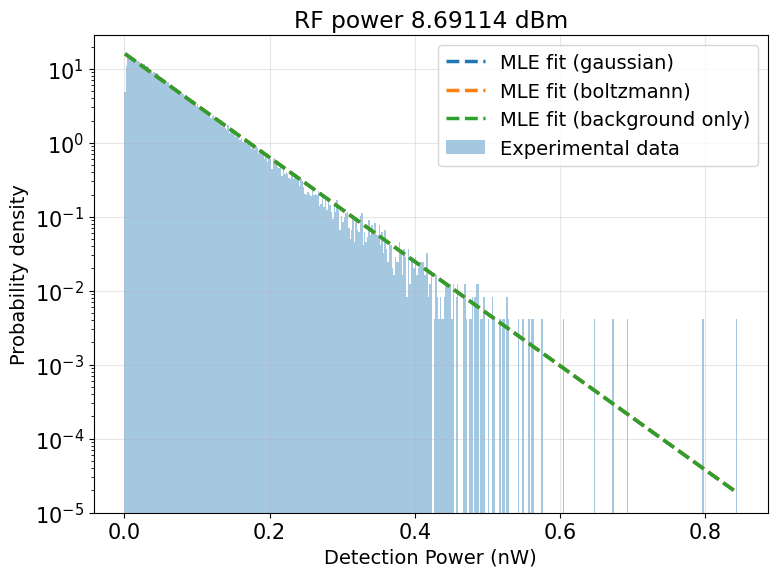

Number of bins used for fitting: 336

========== RESULTS ==========

--- gaussian ---
  p         : 0.00042
  bg_scale  : 0.03258
  mu        : -0.02999
  sigma     : 0.10542
  -logL     : 548804.92   (n_params=4)
  AIC       : 1097617.84

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.03256
  scale     : 0.32525
  -logL     : 548804.80   (n_params=3)
  AIC       : 1097615.60


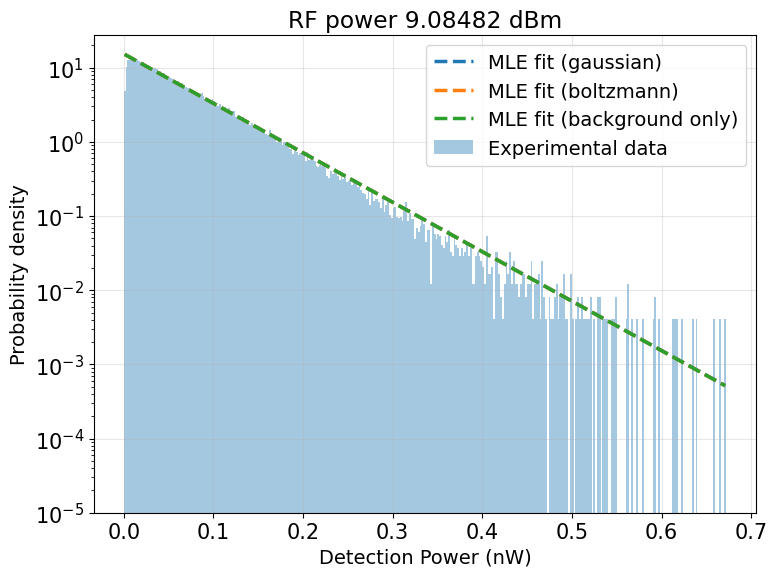

Number of bins used for fitting: 359

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.03502
  mu        : -0.02020
  sigma     : 0.09975
  -logL     : 557712.98   (n_params=4)
  AIC       : 1115433.97

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.03502
  scale     : 0.34989
  -logL     : 557713.00   (n_params=3)
  AIC       : 1115432.00


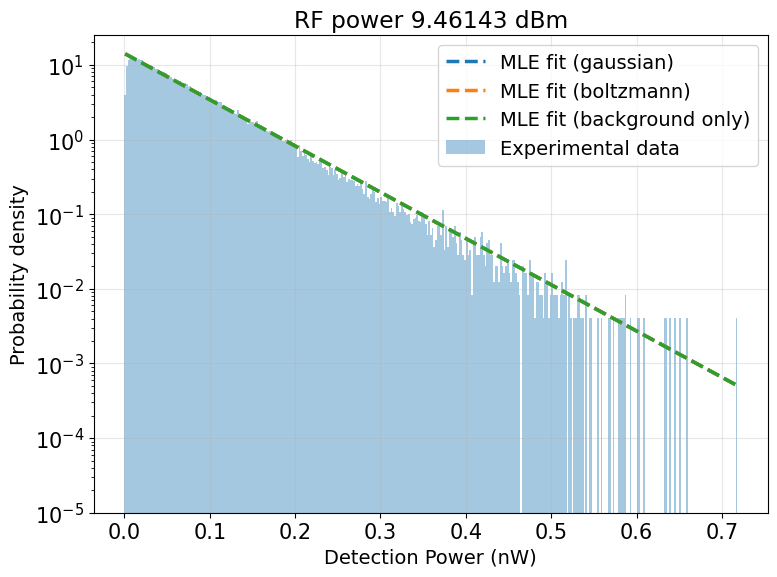

Number of bins used for fitting: 402

========== RESULTS ==========

--- gaussian ---
  p         : 0.00000
  bg_scale  : 0.03707
  mu        : 0.05279
  sigma     : 0.09978
  -logL     : 568148.03   (n_params=4)
  AIC       : 1136304.06

--- boltzmann ---
  p         : 0.00000
  bg_scale  : 0.03707
  scale     : 0.37045
  -logL     : 568148.05   (n_params=3)
  AIC       : 1136302.10


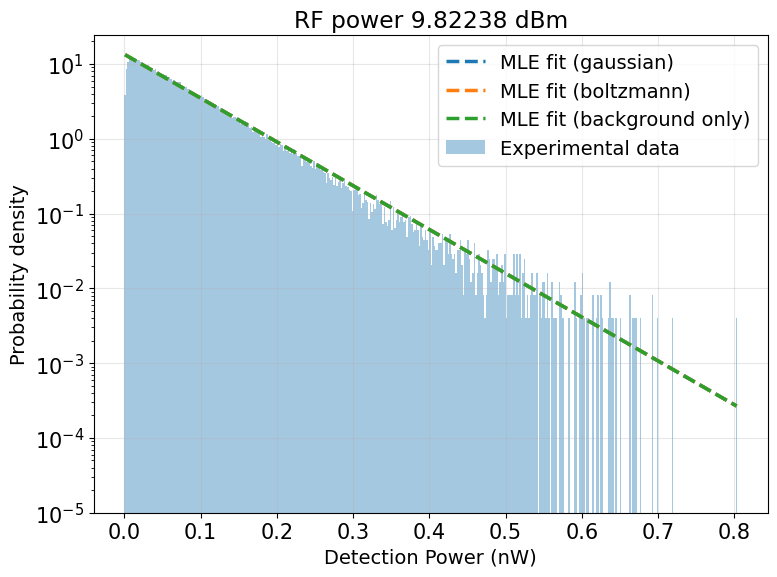

In [236]:
df_chi = 2
all_dBm = df['dBm']
all_data = [] 
for P in range(len(all_dBm)): 
    data = dBm_to_W(np.array(df['data'][P]))*1e9
    power = data
    data_label = "Experimental data"
    # ============================================================
    # 5) Bin the data once (used for BOTH fitting and plotting)
    # ============================================================

    bin_size = 0.002
    bin_edges = np.arange(0, power.max() + bin_size, bin_size)
    bin_counts, _ = np.histogram(power, bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    print(f"Number of bins used for fitting: {len(bin_centers)}")

    # ============================================================
    # 6) Fit multiple candidate models and compare
    # ============================================================

    MODELS_TO_COMPARE = ["gaussian", "boltzmann"]

    fits = {}
    for name in MODELS_TO_COMPARE:
        fits[name] = fit_model(bin_centers, bin_counts, bin_size, df_chi, name, p0 =0.001)

    print()
    print("========== RESULTS ==========")
    for name, fit in fits.items():
        print(f"\n--- {name} ---")
        print(f"  p         : {fit['p']:.5f}")
        print(f"  bg_scale  : {fit['bg_scale']:.5f}")
        for pname, pval in fit["dist_params"].items():
            print(f"  {pname:<9} : {pval:.5f}")
        print(f"  -logL     : {fit['nll']:.2f}   (n_params={fit['n_params']})")
        # AIC for a quick, honest comparison across models with different #params
        aic = 2 * fit["n_params"] + 2 * fit["nll"]
        print(f"  AIC       : {aic:.2f}")

    # ============================================================
    # 7) Plot (reusing the same bins used for fitting)
    # ============================================================

    density = bin_counts / (bin_counts.sum() * bin_size)

    plt.figure(figsize=(8, 6))

    plt.bar(
        bin_edges[:-1],
        density,
        width=bin_size,
        alpha=0.4,
        align='edge',
        label=data_label
    )

    for name, fit in fits.items():
        curve = fitted_pdf(bin_centers, df_chi, fit)
        plt.plot(bin_centers, curve, '--', lw=2.5, label=f"MLE fit ({name})")
    bg_curve = chi2.pdf(bin_centers, df=df_chi, scale=fit['bg_scale'])
    plt.plot(bin_centers, bg_curve, '--', lw=2.5, label=f"MLE fit (background only)")
    plt.yscale('log')
    plt.ylim(1e-5, density.max() * 2)

    plt.xlabel("Detection Power (nW)")
    plt.ylabel("Probability density")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(f"RF power {all_dBm[P]} dBm")

    plt.tight_layout()
    # plt.savefig("/home/claude/pluggable_signal_models_fit.png", dpi=150)
    plt.show()

### Try to analyze the data for each trial by extracting the maximum value

In [201]:
import numpy as np
from scipy import stats
from scipy.optimize import minimize

# --- 1. SET UP THE MIXTURE LOG-LIKELIHOOD FUNCTION ---
def gumbel_mixture_neg_log_lik(params, data):
    """
    Computes the negative log-likelihood of a 2-component Gumbel mixture.
    params: [p, mu1, beta1, mu2, beta2]
    p must be bounded between 0 and 1. betas must be positive.
    """
    p, mu1, beta1, mu2, beta2 = params
    
    # Penalize out-of-bounds parameters during optimization
    if not (0 <= p <= 1) or beta1 <= 0 or beta2 <= 0:
        return 1e10
        
    # Evaluate the PDF of both Gumbel components
    pdf1 = stats.gumbel_r.pdf(data, loc=mu1, scale=beta1)
    pdf2 = stats.gumbel_r.pdf(data, loc=mu2, scale=beta2)
    
    # Combined mixture PDF
    mixed_pdf = (1 - p) * pdf1 + p * pdf2
    
    # Avoid log(0)
    mixed_pdf = np.clip(mixed_pdf, 1e-15, None)
    
    # Return negative log-likelihood (to minimize it)
    return -np.sum(np.log(mixed_pdf))

# --- 2. EXAMPLE DATA GENERATION (For demonstration) ---
# Let's simulate your 100 group maximums where event probability p = 0.30
np.random.seed(42)
true_p = 0.30
n_measurements = 100

my_100_maxima = []
for _ in range(n_measurements):
    if np.random.rand() < true_p:
        # Event happens: Burst data (e.g., higher noncentral chi-square)
        simulated_measurement = np.random.noncentral_chisquare(df=4, nonc=15, size=1000)
    else:
        # Baseline data (e.g., ordinary chi-square)
        simulated_measurement = np.random.chisquare(df=4, size=1000)
    
    my_100_maxima.append(np.max(simulated_measurement))

my_100_maxima = np.array(my_100_maxima)

file = load_h5_data('/home/electron/data/experiment_07092026/RFPowerSweepOnOffDifferential_12-02-31.h5') #load_latest_data()#
data = file['all_meas'] 
file2 = load_h5_data('data/experiment_07062026/RFPowerSweepOnOff_19-06-42_data.h5', base='/home/electron/') 
data2 = file2['all_meas'] 
P_nW = dBm_to_W(np.max(data, axis=1))*1e9 
P_nW_background = dBm_to_W(np.max(data2, axis=1))*1e9
my_100_maxima=P_nW
data_length = len(my_100_maxima)

# --- 3. FIT THE MODEL ---
# Initial guesses: [p, mu1, beta1, mu2, beta2]
# Tip: sort data to guess baseline vs burst properties
sorted_maxima = np.sort(my_100_maxima)
init_p = 0.0
init_mu1 = np.median(P_nW_background)   # Guess baseline center from lower half
init_mu2 = np.median(sorted_maxima[data_length//2:])   # Guess burst center from upper half
init_beta1 = np.std(P_nW_background)
init_beta2 = np.std(sorted_maxima[data_length//2:])

initial_guess = [init_p, init_mu1, init_beta1, init_mu2, init_beta2]

# Define parameter bounds to keep the optimizer on the rails
bounds = [
    (0.0, 1.0),      # p must be between 0 and 1
    (None, None),    # mu1
    (1e-3, None),    # beta1 > 0
    (None, None),    # mu2
    (1e-3, None)     # beta2 > 0
]

# Run the optimization
result = minimize(gumbel_mixture_neg_log_lik, initial_guess, args=(my_100_maxima,), bounds=bounds, method='L-BFGS-B')

# --- 4. EXTRACT RESULTS ---
est_p, est_mu1, est_beta1, est_mu2, est_beta2 = result.x

print("--- Optimization Results ---")
print(f"Estimated Event Probability (p): {est_p * 100:.2f}%")
print(f"Baseline Component: mu = {est_mu1:.2f}, beta = {est_beta1:.2f}")
print(f"Burst Component:    mu = {est_mu2:.2f}, beta = {est_beta2:.2f}")

--- Optimization Results ---
Estimated Event Probability (p): 6.31%
Baseline Component: mu = 0.25, beta = 0.04
Burst Component:    mu = 0.16, beta = 0.02


In [202]:
import numpy as np
from scipy.optimize import minimize
import scipy.stats as stats

# --- Run the optimization exactly as you did before ---
# (Assuming 'result' holds your optimization output)
est_params = result.x  # [p, mu1, beta1, mu2, beta2]

# --- CALCULATING UNCERTAINTY ---

# 1. We need the exact Hessian matrix at the optimum point.
# Since L-BFGS-B only approximates it, we calculate it numerically here:
def numerical_hessian(func, x, epsilon=1e-5, *args):
    """Computes the numerical Hessian matrix of a function"""
    n = len(x)
    hessian = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x_pp = np.array(x, dtype=float); x_pp[i] += epsilon; x_pp[j] += epsilon
            x_pm = np.array(x, dtype=float); x_pp[i] += epsilon; x_pm[j] -= epsilon
            x_mp = np.array(x, dtype=float); x_mp[i] -= epsilon; x_mp[j] += epsilon
            x_mm = np.array(x, dtype=float); x_mm[i] -= epsilon; x_mm[j] -= epsilon
            
            # Finite difference formula
            hessian[i, j] = (func(x_pp, *args) - func(x_pm, *args) - 
                             func(x_mp, *args) + func(x_mm, *args)) / (4 * epsilon**2)
    return hessian

# Calculate Hessian of the negative log-likelihood function at the optimized values
# (Pass your 'my_100_maxima' array as the extra argument)
H = numerical_hessian(gumbel_mixture_neg_log_lik, est_params, 1e-5, my_100_maxima)

try:
    # 2. Invert the Hessian matrix to get the Variance-Covariance Matrix
    cov_matrix = np.linalg.inv(H)
    
    # 3. Standard Errors are the square root of the diagonal elements
    standard_errors = np.sqrt(np.diag(cov_matrix))
    
    # 4. Compute 95% Confidence Intervals (Z = 1.96 for a two-sided 95% CI)
    z_score = 1.96
    conf_intervals = [
        (est - z_score * se, est + z_score * se) 
        for est, se in zip(est_params, standard_errors)
    ]
    
    # --- PRINT THE UNCERTAINTY RESULTS ---
    param_names = ["Probability (p)", "Baseline mu1", "Baseline beta1", "Burst mu2", "Burst beta2"]
    
    print("\n--- Parameter Uncertainty (95% Confidence Intervals) ---")
    for i, name in enumerate(param_names):
        # Scale probability to percentage for readability
        scale = 100 if i == 0 else 1
        unit = "%" if i == 0 else ""
        
        val = est_params[i] * scale
        se = standard_errors[i] * scale
        ci_low = conf_intervals[i][0] * scale
        ci_high = conf_intervals[i][1] * scale
        
        # Enforce physical bounds for CI presentation (e.g. probability can't be < 0)
        if i == 0:
            ci_low = max(0.0, ci_low)
            ci_high = min(100.0, ci_high)
        elif "beta" in name:
            ci_low = max(1e-3, ci_low)

        print(f"{name.ljust(16)}: {val:.2f}{unit} ± {se:.2f}{unit}  |  95% CI: [{ci_low:.2f}{unit}, {ci_high:.2f}{unit}]")

except np.linalg.LinAlgError:
    print("\n[Warning] Hessian matrix was singular and couldn't be inverted.")
    print("This happens if your baseline and burst components overlap too heavily,")
    print("making it difficult for the optimizer to uniquely separate them.")


--- Parameter Uncertainty (95% Confidence Intervals) ---
Probability (p) : 6.31% ± 3.27%  |  95% CI: [0.00%, 12.72%]
Baseline mu1    : 0.25 ± 0.01  |  95% CI: [0.23, 0.26]
Baseline beta1  : 0.04 ± 0.01  |  95% CI: [0.03, 0.05]
Burst mu2       : 0.16 ± 0.01  |  95% CI: [0.15, 0.18]
Burst beta2     : 0.02 ± 0.01  |  95% CI: [0.00, 0.03]


Number of bins used for plotting: 398


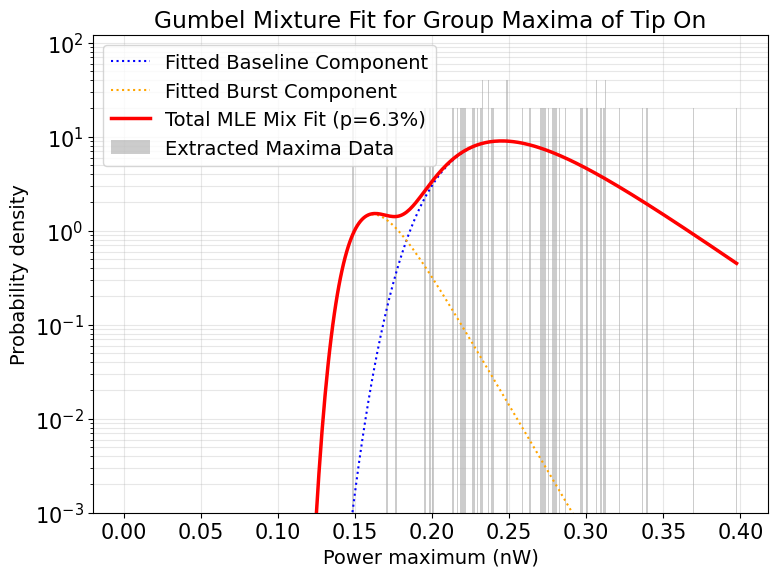

In [205]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# 5) Bin the data once (used for BOTH fitting and plotting)
# ============================================================

# Swap 'power' out for your 100 maximum values array
maxima_data = my_100_maxima  

# Because maximums vary in scale, dynamically choosing 30-50 bins is usually safer, 
# but if you prefer a fixed width, you can use: bin_size = 0.5 (or whatever fits your scale)
bin_size = 0.001
bin_edges = np.arange(0, maxima_data.max() + bin_size, bin_size)
bin_counts, _ = np.histogram(maxima_data, bins=bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

print(f"Number of bins used for plotting: {len(bin_centers)}")

# ============================================================
# 7) Plot (reusing the same bins used for fitting)
# ============================================================

density = bin_counts / (bin_counts.sum() * bin_size)

plt.figure(figsize=(8, 6))

# Plot the empirical maximum values histogram
plt.bar(
    bin_edges[:-1],
    density,
    width=bin_size,
    alpha=0.4,
    align='edge',
    color='gray',
    label='Extracted Maxima Data'
)

# --- Compute the Curves from the MLE Optimization Results ---
# Re-using the optimal parameters from the minimize() output:
# est_p, est_mu1, est_beta1, est_mu2, est_beta2

# Component 1: Baseline Gumbel
curve_baseline = (1 - est_p) * stats.gumbel_r.pdf(bin_centers, loc=est_mu1, scale=est_beta1)

# Component 2: Burst Gumbel
curve_burst = est_p * stats.gumbel_r.pdf(bin_centers, loc=est_mu2, scale=est_beta2)

# Total Mixture Model
curve_total = curve_baseline + curve_burst

# Plot individual components (optional, but incredibly helpful for intuition)
plt.plot(bin_centers, curve_baseline, ':', lw=1.5, color='blue', label='Fitted Baseline Component')
plt.plot(bin_centers, curve_burst, ':', lw=1.5, color='orange', label='Fitted Burst Component')

# Plot the final combined mixture fit
plt.plot(bin_centers, curve_total, '-', lw=2.5, color='red', label=f"Total MLE Mix Fit (p={est_p*100:.1f}%)")

# Handle log scale safely (exclude 0s from the minimum limit calculation)
plt.yscale('log')
nonzero_density = density[density > 0]
if len(nonzero_density) > 0:
    plt.ylim(1e-3, density.max() * 3)

plt.xlabel("Power maximum (nW)")
plt.ylabel("Probability density")
plt.title("Gumbel Mixture Fit for Group Maxima of Tip On")
plt.grid(alpha=0.3, which="both") # 'both' ensures gridlines show up on log scales
plt.legend()

plt.tight_layout()
# plt.savefig("gumbel_mixture_fit.png", dpi=150)
plt.show()